# Beyond the Likes: Uncovering the Patterns Behind Social Media Content Performance

## Data Analysis Project

This project investigates the patterns associated with social media content performance by examining the relationships between audience characteristics, content characteristics, posting behaviour, platform, and engagement.

## 1. Introduction

Social media platforms generate large amounts of engagement data, but high visibility does not necessarily translate into high audience interaction. This project investigates the patterns associated with social media content performance by examining how engagement varies across platforms, content formats, influencer tiers, audience size, posting behaviour, and other content characteristics.

The analysis combines exploratory data analysis, descriptive statistics, correlation analysis, and non-parametric statistical tests to identify meaningful patterns in engagement performance.

## 2. Research Questions

1. How does engagement rate vary across different social media platforms?

2. How does content type influence engagement rate?

3. Does influencer tier have a significant association with engagement rate?

4. What relationships exist between engagement rate and numerical post characteristics such as likes, comments, shares, views, saves, follower count, hashtag count, content length, and posting time?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

os.getcwd()

'c:\\Users\\HP\\Desktop\\python-data-analysis'

In [5]:
os.listdir()

['.git',
 'python-data-analysis',
 'README.md',
 'social_media_content_performance.ipynb',
 'social_media_engagement_dataset (2).csv']

In [6]:
import pandas as pd

df = pd.read_csv("social_media_engagement_dataset (2).csv")

In [7]:
df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


In [8]:
df.shape

(5000, 20)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   str    
 1   Timestamp        5000 non-null   str    
 2   Platform         5000 non-null   str    
 3   Content_Type     5000 non-null   str    
 4   Category         5000 non-null   str    
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   str    
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   str    
 17  Influencer_Tier  5000 non

In [10]:
df.isnull().sum()

Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Post_ID"].duplicated().sum()

np.int64(0)

In [13]:
print("Platforms:")
print(df["Platform"].unique())

print("\nContent Types:")
print(df["Content_Type"].unique())

print("\nCategories:")
print(df["Category"].unique())

print("\nSentiments:")
print(df["Sentiment"].unique())

print("\nInfluencer Tiers:")
print(df["Influencer_Tier"].unique())

Platforms:
<ArrowStringArray>
['Instagram', 'LinkedIn', 'Facebook', 'Twitter', 'YouTube', 'TikTok']
Length: 6, dtype: str

Content Types:
<ArrowStringArray>
[      'Carousel',       'Document',          'Video',          'Photo',
           'Poll',         'Thread',           'Live',           'Reel',
           'Post',          'Story',          'Short',          'Tweet',
        'Retweet',        'Article',           'Duet',         'Stitch',
 'Community Post']
Length: 17, dtype: str

Categories:
<ArrowStringArray>
[     'Business',        'Health',          'Food',        'Sports',
       'Fitness',     'Lifestyle',     'Education',        'Travel',
 'Entertainment',    'Technology',        'Gaming',       'Fashion']
Length: 12, dtype: str

Sentiments:
<ArrowStringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

Influencer Tiers:
<ArrowStringArray>
['Macro', 'Mid-tier', 'Micro', 'Nano']
Length: 4, dtype: str


In [151]:
df.describe()

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7536.838400,339.898800,835.233400,110968.397000,753.150600,249959.204000,11.960148,11.562600,14.755800,754.508400
std,10169.129568,399.813585,1013.769853,181287.350216,932.653475,144592.908235,71.462053,6.946577,8.666117,576.334039
min,18.000000,1.000000,2.000000,527.000000,5.000000,543.000000,0.050000,0.000000,0.000000,15.000000
25%,1707.750000,96.000000,177.000000,18506.750000,200.000000,124560.250000,1.030000,5.000000,7.000000,280.000000
50%,4073.500000,212.000000,427.500000,40663.500000,424.000000,248930.500000,2.300000,12.000000,15.000000,549.000000
75%,7783.000000,377.000000,1111.500000,84226.750000,805.000000,374697.500000,6.245000,18.000000,22.000000,1226.250000
max,49949.000000,1999.000000,4997.000000,999256.000000,4985.000000,499815.000000,3510.460000,23.000000,29.000000,1999.000000


In [152]:
df["Platform"].value_counts()

Platform
Instagram    1283
Twitter       994
Facebook      984
TikTok        758
LinkedIn      502
YouTube       479
Name: count, dtype: int64

In [153]:
df["Content_Type"].value_counts()

Content_Type
Video             616
Story             568
Poll              384
Post              378
Live              358
Carousel          333
Photo             320
Reel              306
Stitch            259
Retweet           251
Duet              248
Tweet             239
Thread            236
Community Post    135
Document          132
Short             121
Article           116
Name: count, dtype: int64

In [154]:
df["Category"].value_counts()

Category
Gaming           476
Technology       434
Lifestyle        433
Entertainment    432
Fashion          428
Food             413
Education        413
Sports           401
Travel           398
Health           397
Fitness          393
Business         382
Name: count, dtype: int64

In [11]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [12]:
df["Timestamp"].dtype

dtype('<M8[us]')

In [13]:
df[["Timestamp"]].head()

,Timestamp
0,2024-01-01 01:42:00
1,2024-01-01 05:05:00
2,2024-01-01 09:18:00
3,2024-01-01 10:58:00
4,2024-01-01 13:12:00


In [14]:
print("Start date:", df["Timestamp"].min())
print("End date:", df["Timestamp"].max())

Start date: 2024-01-01 01:42:00
End date: 2025-12-31 21:56:00


In [15]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month

In [16]:
df[["Timestamp", "Year", "Month"]].head()

,Timestamp,Year,Month
0,2024-01-01 01:42:00,2024,1
1,2024-01-01 05:05:00,2024,1
2,2024-01-01 09:18:00,2024,1
3,2024-01-01 10:58:00,2024,1
4,2024-01-01 13:12:00,2024,1


In [17]:
df.shape

(5000, 22)

## 3. Exploratory Data Analysis

The exploratory data analysis begins by examining the distribution of key performance metrics. This establishes a baseline understanding of how social media content performs before investigating the factors associated with differences in performance.

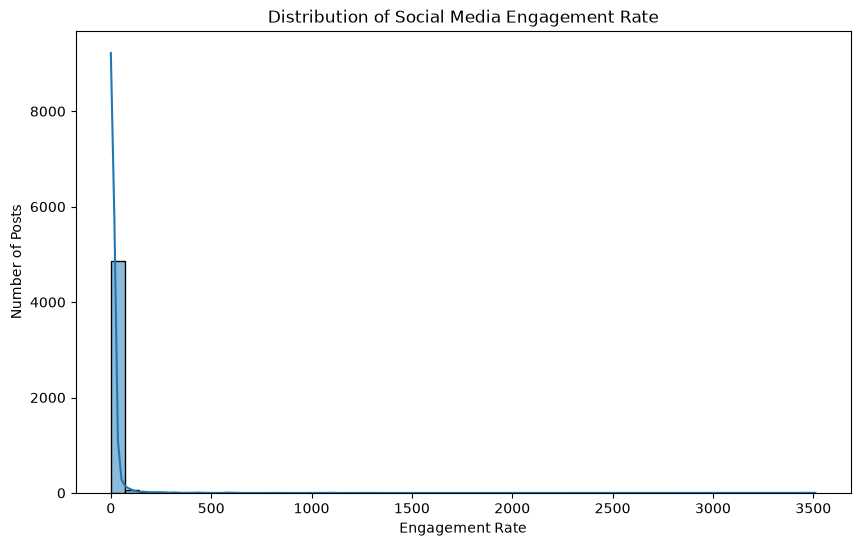

In [162]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Engagement_Rate"], bins=50, kde=True)

plt.title("Distribution of Social Media Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Number of Posts")

plt.show()

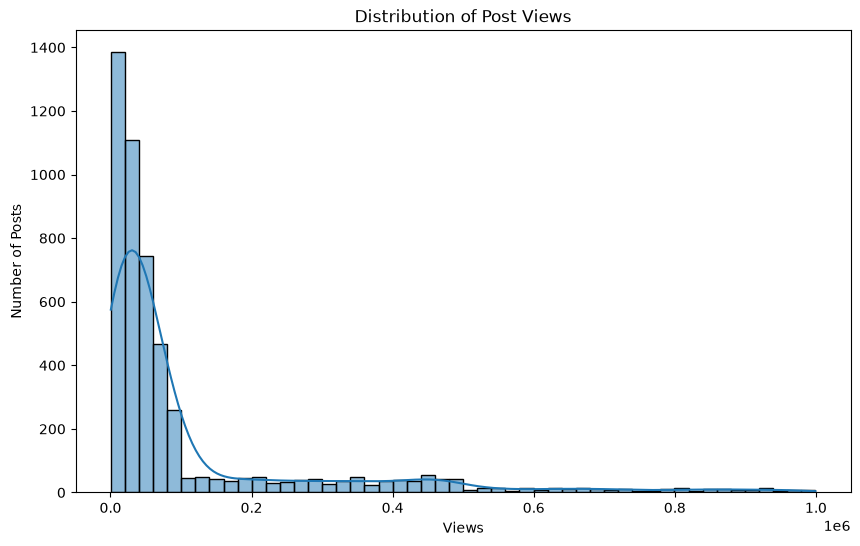

In [163]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Views"], bins=50, kde=True)

plt.title("Distribution of Post Views")
plt.xlabel("Views")
plt.ylabel("Number of Posts")

plt.show()

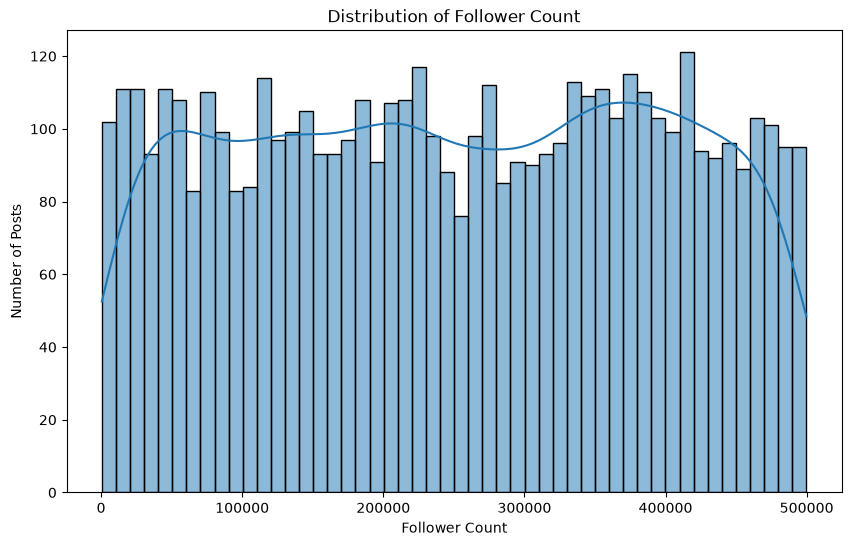

In [164]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Follower_Count"], bins=50, kde=True)

plt.title("Distribution of Follower Count")
plt.xlabel("Follower Count")
plt.ylabel("Number of Posts")

plt.show()

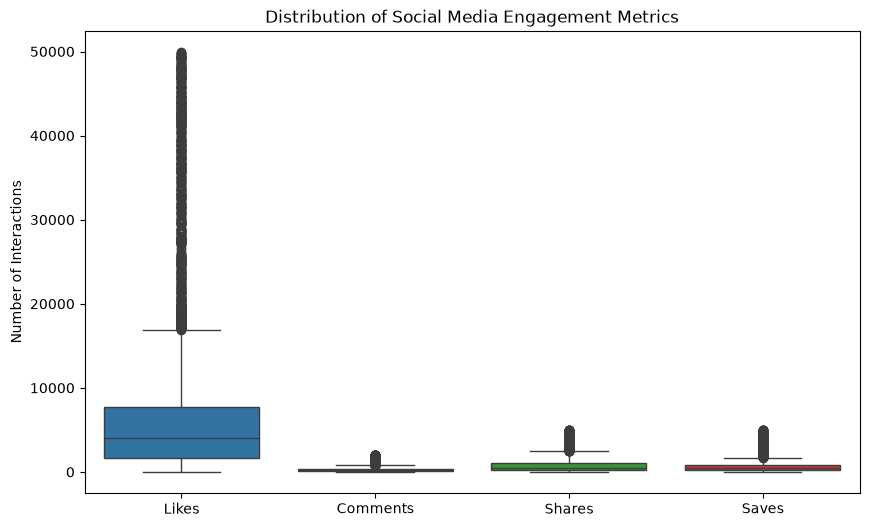

In [165]:
engagement_metrics = ["Likes", "Comments", "Shares", "Saves"]

plt.figure(figsize=(10, 6))

sns.boxplot(data=df[engagement_metrics])

plt.title("Distribution of Social Media Engagement Metrics")
plt.ylabel("Number of Interactions")

plt.show()

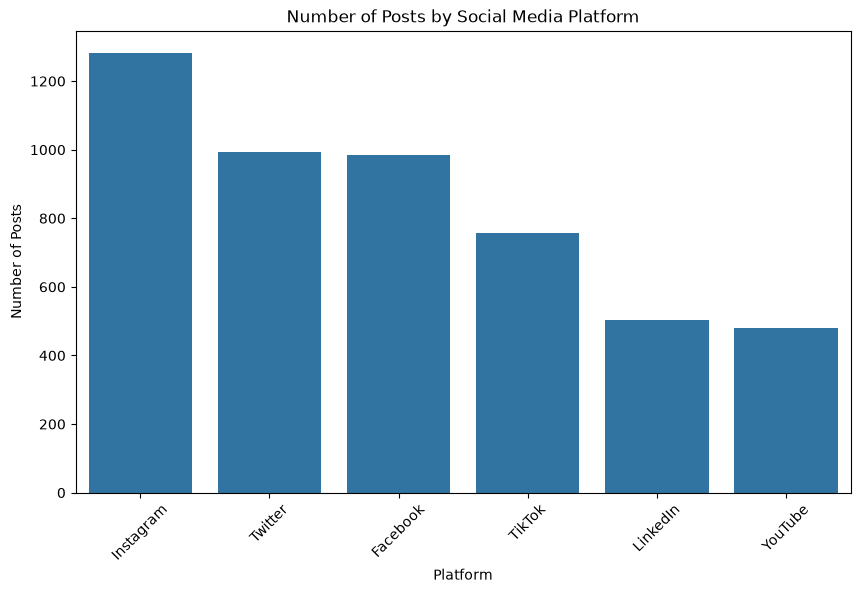

In [28]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Platform",
    order=df["Platform"].value_counts().index
)

plt.title("Number of Posts by Social Media Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.show()

In [29]:
platform_engagement = (
    df.groupby("Platform")["Engagement_Rate"]
    .median()
    .sort_values(ascending=False)
)

platform_engagement

Platform
TikTok       11.015
YouTube       4.140
Instagram     2.120
Facebook      2.005
Twitter       1.420
LinkedIn      0.560
Name: Engagement_Rate, dtype: float64

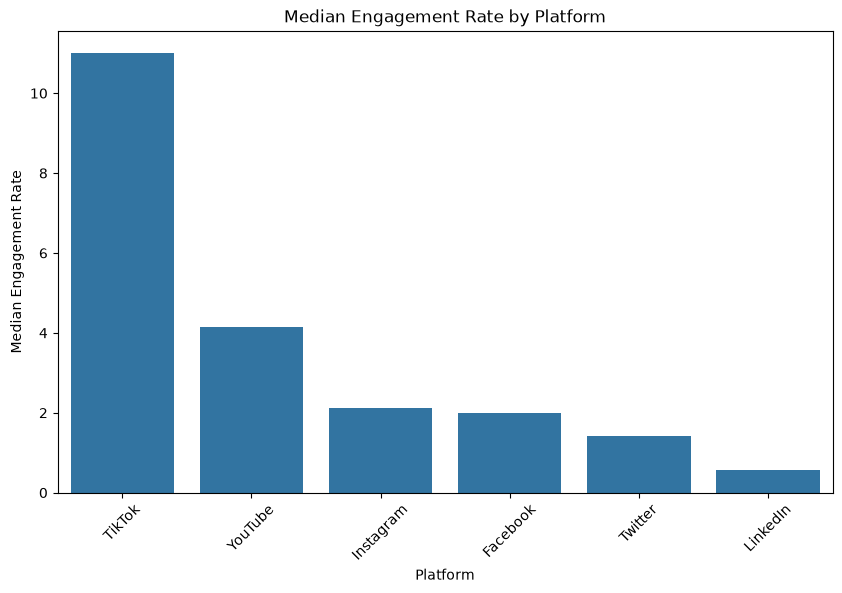

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=platform_engagement.index,
    y=platform_engagement.values
)

plt.title("Median Engagement Rate by Platform")
plt.xlabel("Platform")
plt.ylabel("Median Engagement Rate")

plt.xticks(rotation=45)

plt.show()

## 4.1 Does Reach Translate Into Engagement?

A high number of views indicates that content reached a large audience, but reach does not necessarily imply strong audience interaction. This analysis examines whether posts with more views also tend to have higher engagement rates.

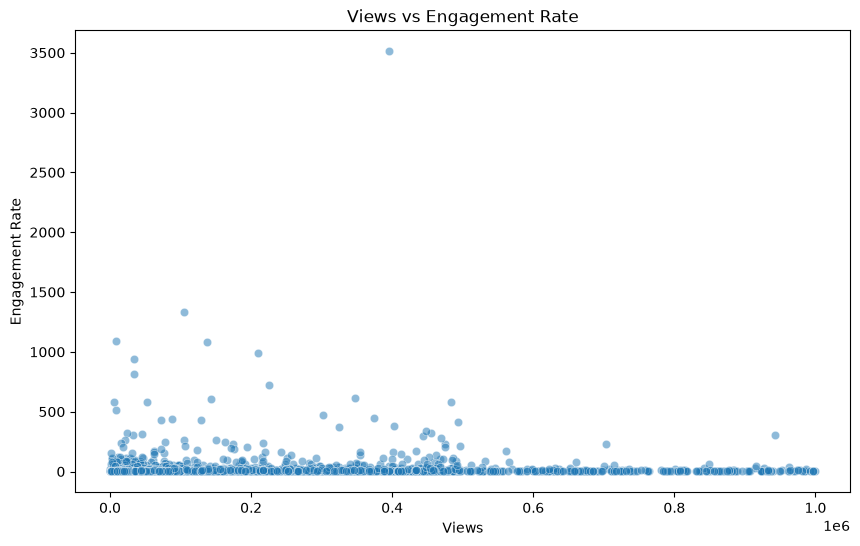

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Views",
    y="Engagement_Rate",
    alpha=0.5
)

plt.title("Views vs Engagement Rate")
plt.xlabel("Views")
plt.ylabel("Engagement Rate")

plt.show()

In [32]:
views_engagement_corr = df["Views"].corr(df["Engagement_Rate"])

views_engagement_corr

np.float64(0.07797980630356181)

## 4.2 Does Audience Size Guarantee Engagement?

Follower count represents the potential audience available to an account. This analysis examines whether accounts with larger audiences consistently achieve higher engagement rates.

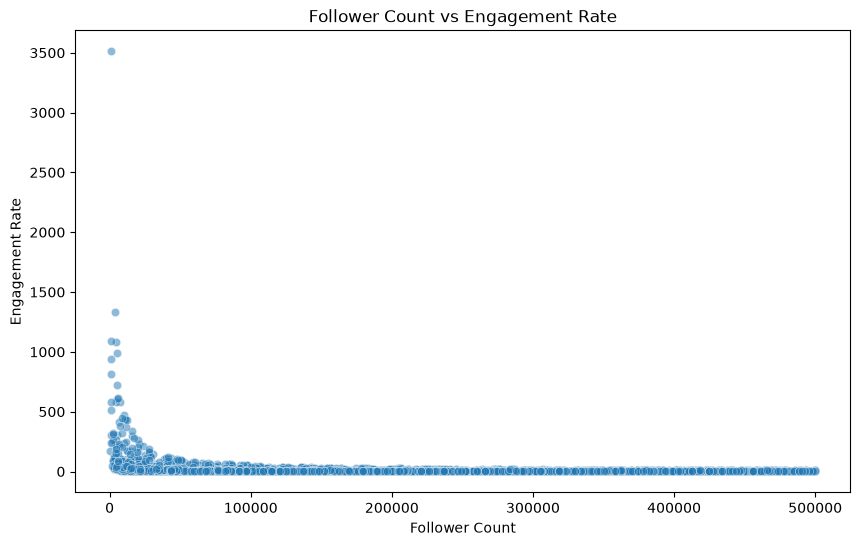

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Follower_Count",
    y="Engagement_Rate",
    alpha=0.5
)

plt.title("Follower Count vs Engagement Rate")
plt.xlabel("Follower Count")
plt.ylabel("Engagement Rate")

plt.show()

In [34]:
followers_engagement_corr = df["Follower_Count"].corr(
    df["Engagement_Rate"]
)

followers_engagement_corr

np.float64(-0.20505214946425054)

In [35]:
followers_views_corr = df["Follower_Count"].corr(
    df["Views"]
)

followers_views_corr

np.float64(0.02397750201882546)

In [36]:
correlation_columns = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Follower_Count",
    "Engagement_Rate",
    "Hashtag_Count",
    "Content_Length"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hashtag_Count,Content_Length
Likes,1.000000,0.605336,0.557194,0.375491,0.433926,0.003815,0.234692,0.005654,-0.304640
Comments,0.605336,1.000000,0.522609,0.412638,0.434245,0.045063,0.137186,-0.004010,-0.309749
Shares,0.557194,0.522609,1.000000,0.359635,0.337475,0.003060,0.122519,0.006765,-0.233264
Views,0.375491,0.412638,0.359635,1.000000,0.623553,0.023978,0.077980,0.002094,-0.263855
Saves,0.433926,0.434245,0.337475,0.623553,1.000000,0.030640,0.082644,0.004246,-0.278678
Follower_Count,0.003815,0.045063,0.003060,0.023978,0.030640,1.000000,-0.205052,0.020527,0.004189
Engagement_Rate,0.234692,0.137186,0.122519,0.077980,0.082644,-0.205052,1.000000,-0.006163,-0.065373
Hashtag_Count,0.005654,-0.004010,0.006765,0.002094,0.004246,0.020527,-0.006163,1.000000,-0.000116
Content_Length,-0.304640,-0.309749,-0.233264,-0.263855,-0.278678,0.004189,-0.065373,-0.000116,1.000000


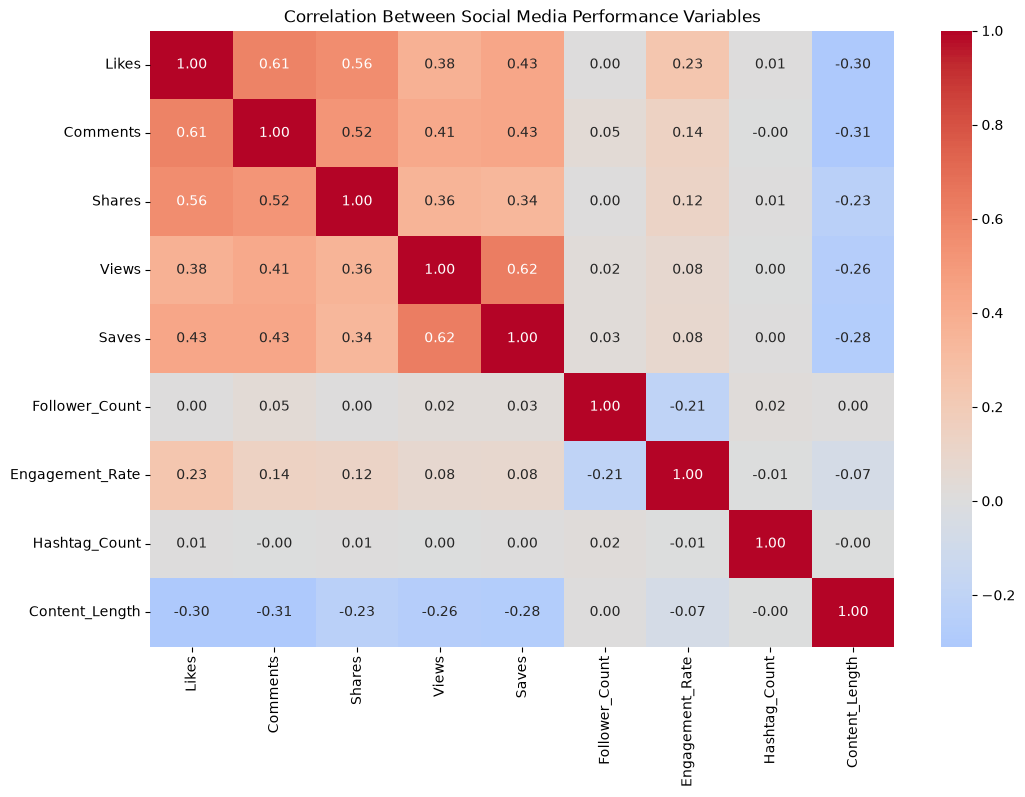

In [37]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Social Media Performance Variables")

plt.show()

### Initial Findings

The relationship analysis will be used to determine whether reach and audience size are associated with engagement. Particular attention will be given to the relationships between follower count, views, and engagement rate.

The correlation results will be interpreted as associations rather than causal relationships. Because engagement rate is highly skewed, extreme observations will also be considered when interpreting the results.

## 5.1 Does Content Type Matter?

Different formats may encourage different levels of audience interaction. This analysis compares engagement across content types to determine whether certain formats are associated with stronger content performance.

In [38]:
content_type_engagement = (
    df.groupby("Content_Type")["Engagement_Rate"]
    .median()
    .sort_values(ascending=False)
)

content_type_engagement

Content_Type
Duet              11.545
Stitch            10.680
Video              4.560
Short              3.950
Community Post     3.910
Live               2.410
Carousel           2.250
Photo              2.125
Reel               2.040
Story              2.020
Post               1.785
Tweet              1.490
Retweet            1.390
Thread             1.315
Poll               1.150
Document           0.590
Article            0.580
Name: Engagement_Rate, dtype: float64

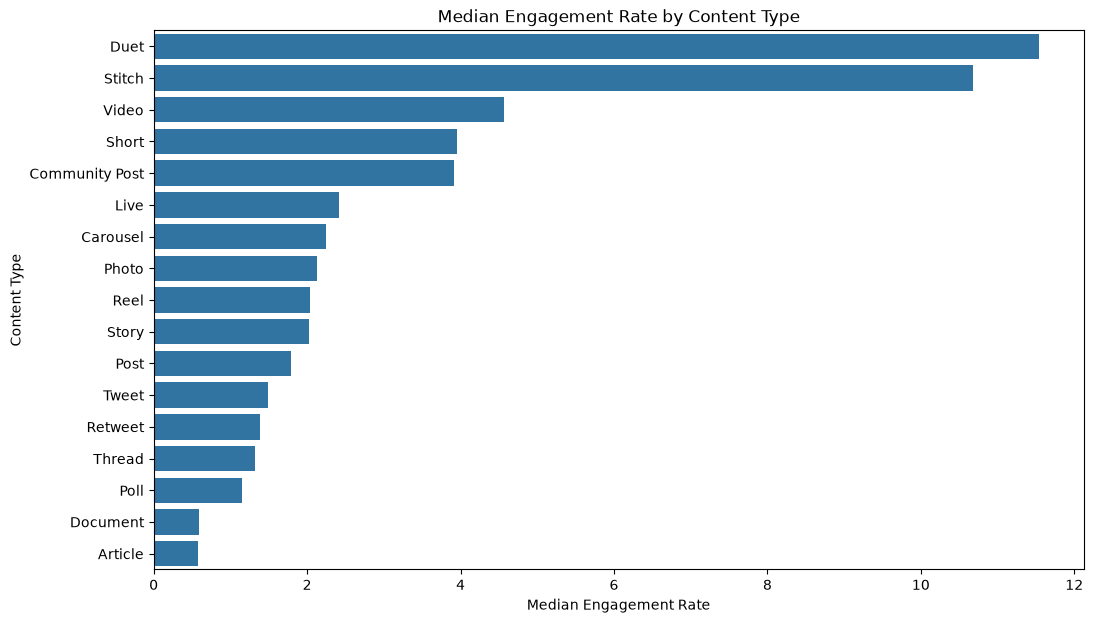

In [39]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=content_type_engagement.values,
    y=content_type_engagement.index
)

plt.title("Median Engagement Rate by Content Type")
plt.xlabel("Median Engagement Rate")
plt.ylabel("Content Type")

plt.show()

In [40]:
content_type_summary = (
    df.groupby("Content_Type")
      .agg(
          Posts=("Post_ID", "count"),
          Median_Engagement=("Engagement_Rate", "median"),
          Mean_Engagement=("Engagement_Rate", "mean")
      )
      .sort_values("Median_Engagement", ascending=False)
)

content_type_summary

,Posts,Median_Engagement,Mean_Engagement
Content_Type,,,
Duet,248,11.545,41.630242
Stitch,259,10.680,45.382664
Video,616,4.560,20.407987
Short,121,3.950,10.744628
Community Post,135,3.910,10.188222
Live,358,2.410,7.408827
Carousel,333,2.250,8.376246
Photo,320,2.125,6.283531
Reel,306,2.040,11.674739


## 5.2 Does Content Topic Matter?

Content is published across different categories such as gaming, technology, lifestyle, entertainment, and education. This analysis examines whether the subject of a post is associated with differences in engagement.

In [41]:
category_engagement = (
    df.groupby("Category")["Engagement_Rate"]
    .median()
    .sort_values(ascending=False)
)

category_engagement

Category
Travel           2.635
Technology       2.605
Lifestyle        2.520
Entertainment    2.390
Education        2.370
Fitness          2.360
Sports           2.360
Food             2.300
Gaming           2.245
Health           2.190
Fashion          1.980
Business         1.900
Name: Engagement_Rate, dtype: float64

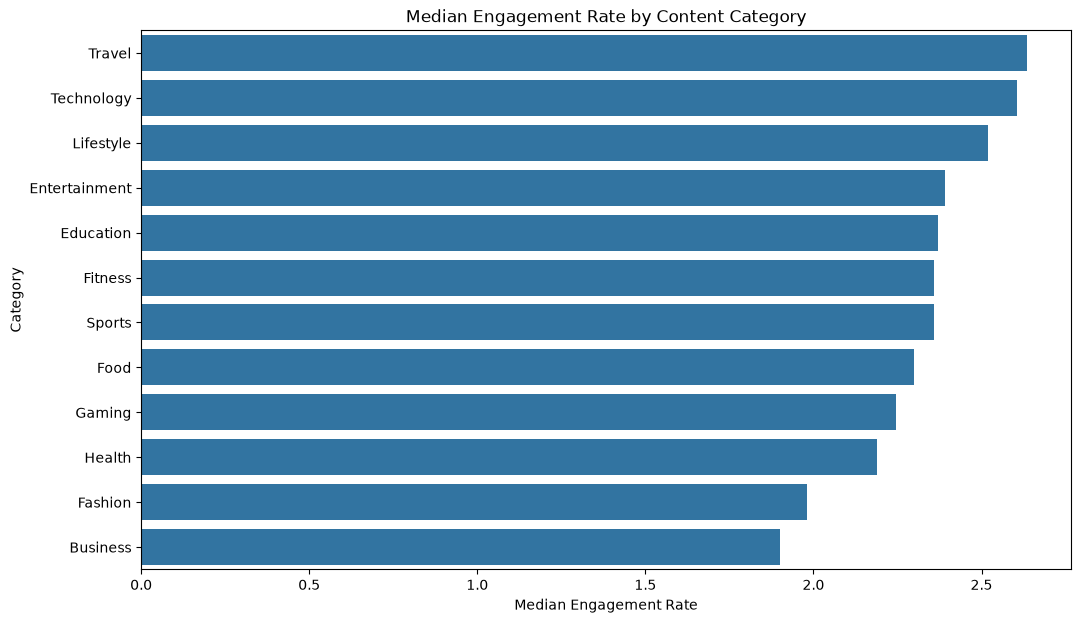

In [42]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=category_engagement.values,
    y=category_engagement.index
)

plt.title("Median Engagement Rate by Content Category")
plt.xlabel("Median Engagement Rate")
plt.ylabel("Category")

plt.show()

In [43]:
category_summary = (
    df.groupby("Category")
      .agg(
          Posts=("Post_ID", "count"),
          Median_Engagement=("Engagement_Rate", "median"),
          Mean_Engagement=("Engagement_Rate", "mean")
      )
      .sort_values("Median_Engagement", ascending=False)
)

category_summary

,Posts,Median_Engagement,Mean_Engagement
Category,,,
Travel,398,2.635,15.206231
Technology,434,2.605,13.960968
Lifestyle,433,2.520,19.127921
Entertainment,432,2.390,11.565625
Education,413,2.370,11.890121
Fitness,393,2.360,10.378702
Sports,401,2.360,9.535611
Food,413,2.300,12.953535
Gaming,476,2.245,9.912857


## 5.3 Does Sentiment Relate to Engagement?

The sentiment of content may influence how audiences respond to posts. Engagement will therefore be compared across positive, neutral, and negative content.

In [44]:
sentiment_summary = (
    df.groupby("Sentiment")
      .agg(
          Posts=("Post_ID", "count"),
          Median_Engagement=("Engagement_Rate", "median"),
          Mean_Engagement=("Engagement_Rate", "mean")
      )
      .sort_values("Median_Engagement", ascending=False)
)

sentiment_summary

,Posts,Median_Engagement,Mean_Engagement
Sentiment,,,
Negative,750,2.42,11.869493
Positive,2503,2.37,12.901035
Neutral,1747,2.13,10.651019


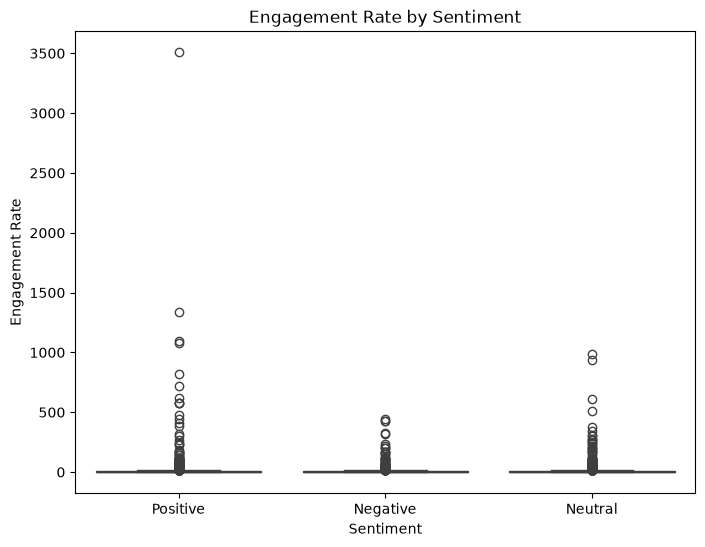

In [45]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Sentiment",
    y="Engagement_Rate"
)

plt.title("Engagement Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Engagement Rate")

plt.show()

## 5.4 Does Media Presence Matter?

The analysis examines whether posts containing media demonstrate different engagement patterns from posts without media.

In [46]:
media_summary = (
    df.groupby("Has_Media")
      .agg(
          Posts=("Post_ID", "count"),
          Median_Engagement=("Engagement_Rate", "median"),
          Mean_Engagement=("Engagement_Rate", "mean")
      )
)

media_summary

,Posts,Median_Engagement,Mean_Engagement
Has_Media,,,
False,775,2.11,15.618065
True,4225,2.35,11.289169


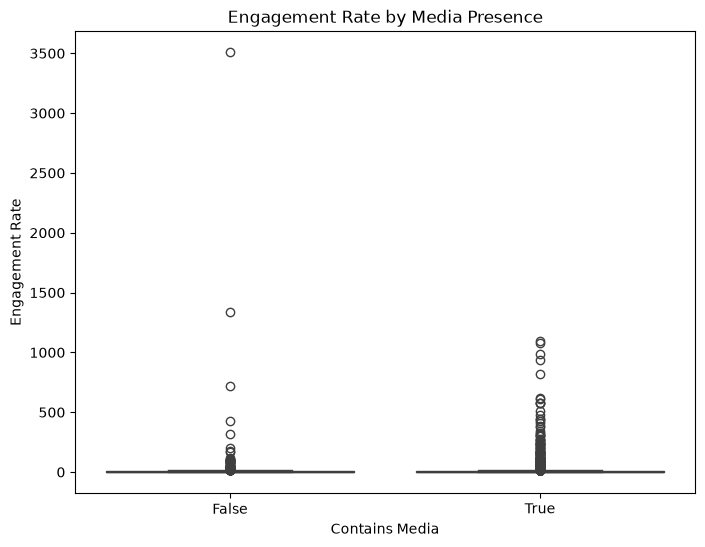

In [47]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Has_Media",
    y="Engagement_Rate"
)

plt.title("Engagement Rate by Media Presence")
plt.xlabel("Contains Media")
plt.ylabel("Engagement Rate")

plt.show()

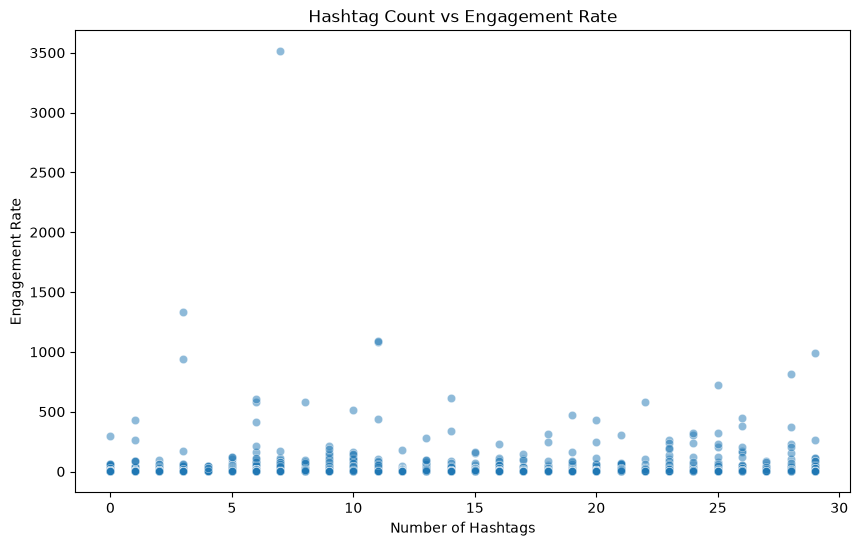

In [48]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Hashtag_Count",
    y="Engagement_Rate",
    alpha=0.5
)

plt.title("Hashtag Count vs Engagement Rate")
plt.xlabel("Number of Hashtags")
plt.ylabel("Engagement Rate")

plt.show()

In [49]:
hashtag_engagement_corr = df["Hashtag_Count"].corr(
    df["Engagement_Rate"]
)

hashtag_engagement_corr

np.float64(-0.006163020012044726)

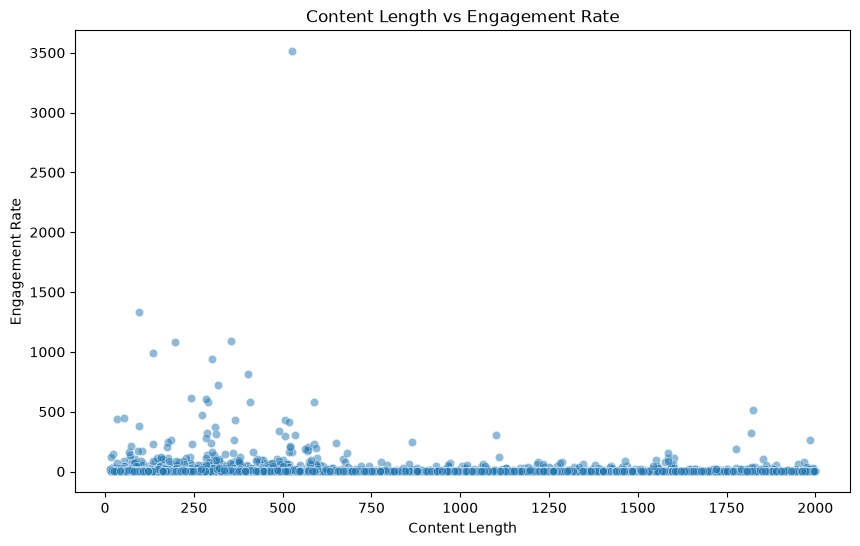

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Content_Length",
    y="Engagement_Rate",
    alpha=0.5
)

plt.title("Content Length vs Engagement Rate")
plt.xlabel("Content Length")
plt.ylabel("Engagement Rate")

plt.show()

In [51]:
content_length_corr = df["Content_Length"].corr(
    df["Engagement_Rate"]
)

content_length_corr

np.float64(-0.06537328962307412)

In [52]:
platform_content = (
    df.groupby(["Platform", "Content_Type"])["Engagement_Rate"]
      .median()
      .reset_index()
)

platform_content.head()

,Platform,Content_Type,Engagement_Rate
0,Facebook,Live,1.760
1,Facebook,Post,2.455
2,Facebook,Story,1.840
3,Facebook,Video,2.010
4,Instagram,Carousel,2.250


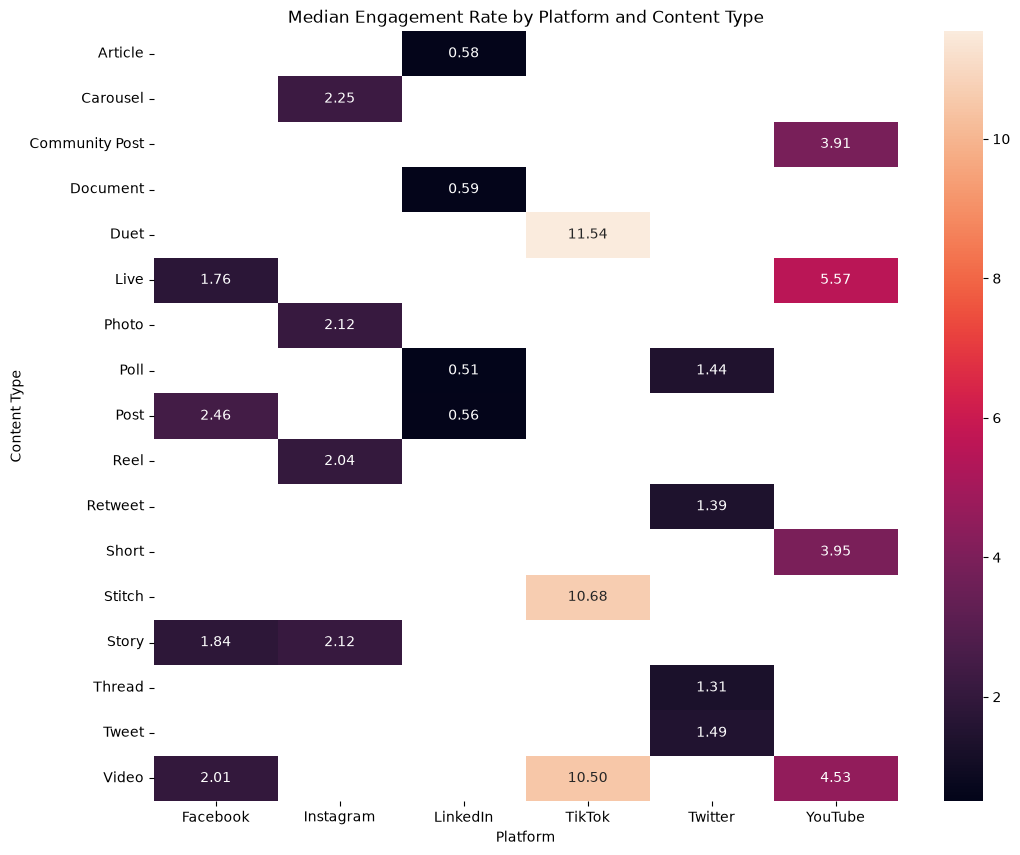

In [53]:
platform_content_pivot = platform_content.pivot(
    index="Content_Type",
    columns="Platform",
    values="Engagement_Rate"
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    platform_content_pivot,
    annot=True,
    fmt=".2f"
)

plt.title("Median Engagement Rate by Platform and Content Type")
plt.xlabel("Platform")
plt.ylabel("Content Type")

plt.show()

## 6.1 Does Posting Time Matter?

Social media audiences may respond differently depending on when content is published. This analysis examines whether engagement varies across different hours of the day.

In [54]:
hourly_engagement = (
    df.groupby("Hour_of_Day")["Engagement_Rate"]
      .median()
      .sort_index()
)

hourly_engagement

Hour_of_Day
0     2.020
1     2.270
2     2.055
3     2.160
4     2.070
5     2.100
6     2.235
7     2.560
8     1.895
9     1.960
10    2.050
11    2.545
12    2.240
13    2.520
14    2.610
15    2.620
16    2.810
17    2.255
18    2.255
19    2.390
20    2.750
21    2.145
22    2.775
23    2.055
Name: Engagement_Rate, dtype: float64

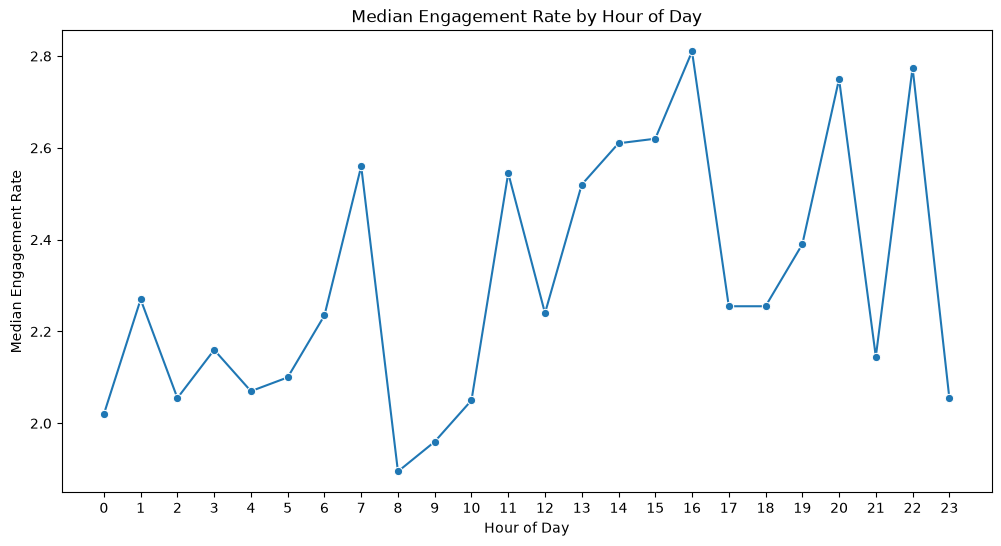

In [55]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_engagement.index,
    y=hourly_engagement.values,
    marker="o"
)

plt.title("Median Engagement Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Median Engagement Rate")
plt.xticks(range(24))

plt.show()

In [56]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_engagement = (
    df.groupby("Day_of_Week")["Engagement_Rate"]
      .median()
      .reindex(day_order)
)

daily_engagement

Day_of_Week
Monday       2.160
Tuesday      2.260
Wednesday    2.370
Thursday     2.540
Friday       2.370
Saturday     2.030
Sunday       2.315
Name: Engagement_Rate, dtype: float64

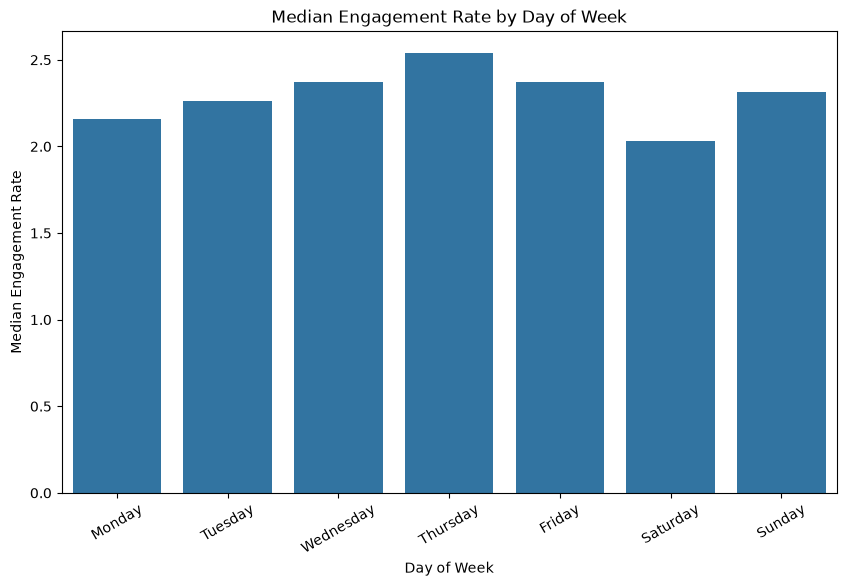

In [57]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=daily_engagement.index,
    y=daily_engagement.values
)

plt.title("Median Engagement Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Median Engagement Rate")

plt.xticks(rotation=30)

plt.show()

In [58]:
platform_hour = (
    df.groupby(["Platform", "Hour_of_Day"])["Engagement_Rate"]
      .median()
      .reset_index()
)

In [59]:
platform_hour_pivot = platform_hour.pivot(
    index="Hour_of_Day",
    columns="Platform",
    values="Engagement_Rate"
)

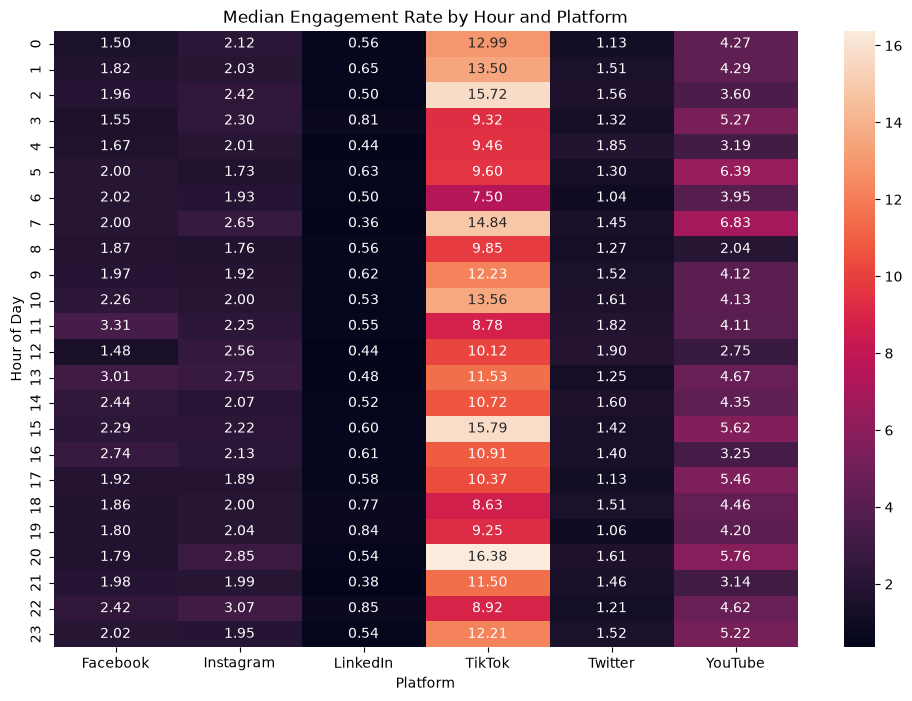

In [60]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    platform_hour_pivot,
    annot=True,
    fmt=".2f"
)

plt.title("Median Engagement Rate by Hour and Platform")
plt.xlabel("Platform")
plt.ylabel("Hour of Day")

plt.show()

In [61]:
best_platform_hours = (
    platform_hour.loc[
        platform_hour.groupby("Platform")["Engagement_Rate"].idxmax()
    ]
    .sort_values("Platform")
)

best_platform_hours

,Platform,Hour_of_Day,Engagement_Rate
11,Facebook,11,3.310
46,Instagram,22,3.070
70,LinkedIn,22,0.850
92,TikTok,20,16.375
108,Twitter,12,1.900
127,YouTube,7,6.830


In [62]:
platform_day = (
    df.groupby(["Platform", "Day_of_Week"])["Engagement_Rate"]
      .median()
      .reset_index()
)

In [63]:
platform_day_pivot = platform_day.pivot(
    index="Day_of_Week",
    columns="Platform",
    values="Engagement_Rate"
).reindex(day_order)

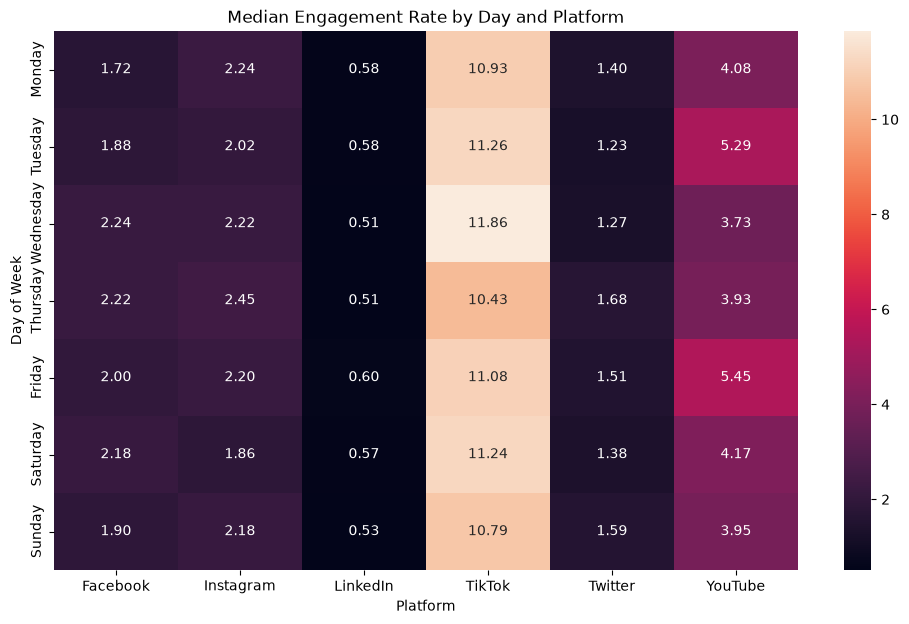

In [64]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    platform_day_pivot,
    annot=True,
    fmt=".2f"
)

plt.title("Median Engagement Rate by Day and Platform")
plt.xlabel("Platform")
plt.ylabel("Day of Week")

plt.show()

In [65]:
def time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time_Period"] = df["Hour_of_Day"].apply(time_period)

In [66]:
df["Time_Period"].value_counts()

Time_Period
Night        1712
Morning      1411
Afternoon    1053
Evening       824
Name: count, dtype: int64

In [67]:
time_period_engagement = (
    df.groupby("Time_Period")["Engagement_Rate"]
      .median()
      .sort_values(ascending=False)
)

time_period_engagement

Time_Period
Afternoon    2.520
Evening      2.375
Night        2.195
Morning      2.160
Name: Engagement_Rate, dtype: float64

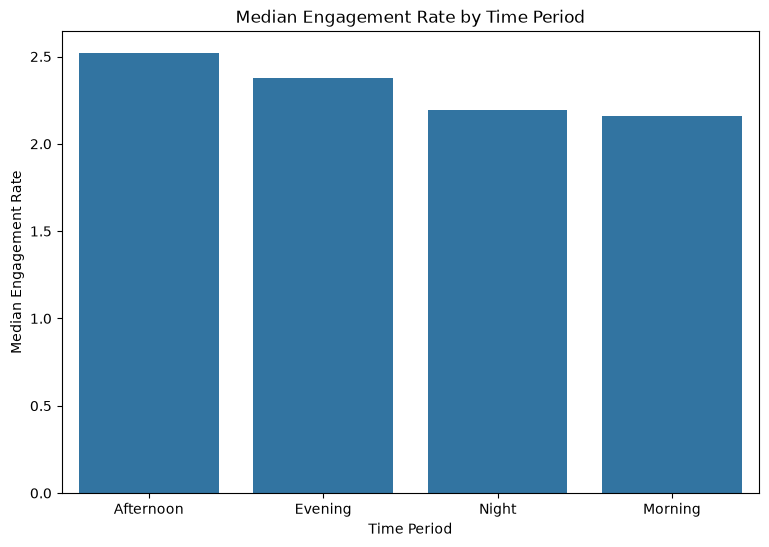

In [68]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=time_period_engagement.index,
    y=time_period_engagement.values
)

plt.title("Median Engagement Rate by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Median Engagement Rate")

plt.show()

In [69]:
platform_time = (
    df.groupby(["Platform", "Time_Period"])["Engagement_Rate"]
      .median()
      .reset_index()
)

platform_time_pivot = platform_time.pivot(
    index="Time_Period",
    columns="Platform",
    values="Engagement_Rate"
)

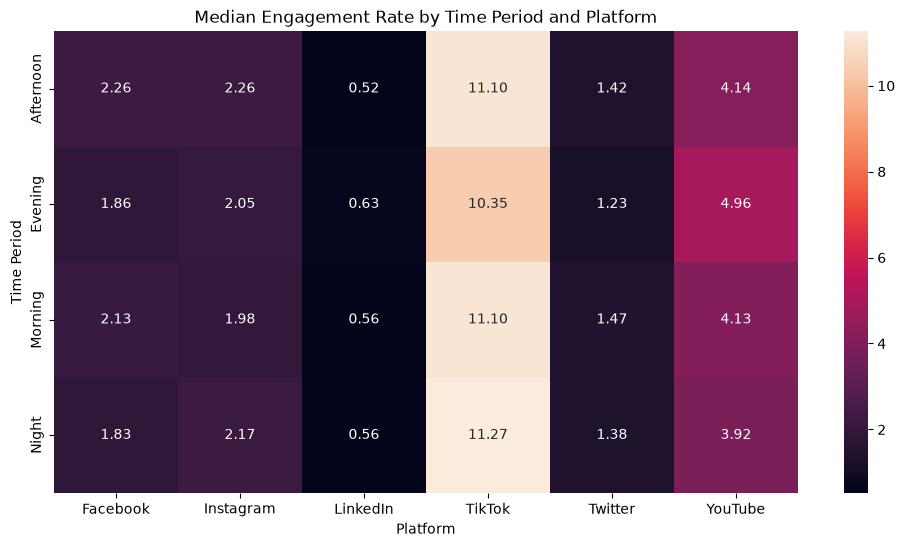

In [70]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    platform_time_pivot,
    annot=True,
    fmt=".2f"
)

plt.title("Median Engagement Rate by Time Period and Platform")
plt.xlabel("Platform")
plt.ylabel("Time Period")

plt.show()

In [71]:
engagement_percentiles = df["Engagement_Rate"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

engagement_percentiles

0.25      1.030
0.50      2.300
0.75      6.245
0.90     17.208
0.95     34.596
0.99    167.999
Name: Engagement_Rate, dtype: float64

In [72]:
high_performance_threshold = df["Engagement_Rate"].quantile(0.90)

high_performance_threshold

np.float64(17.208000000000027)

In [73]:
df["Performance_Group"] = np.where(
    df["Engagement_Rate"] >= high_performance_threshold,
    "High Performing",
    "Other"
)

In [74]:
df["Performance_Group"].value_counts()

Performance_Group
Other              4500
High Performing     500
Name: count, dtype: int64

In [75]:
high_performers = df[
    df["Performance_Group"] == "High Performing"
]

high_performers.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,...,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified,Year,Month,Time_Period,Performance_Group
26,POST_02032,2024-01-05 10:15:00,Facebook,Story,Lifestyle,2672,360,464,2203,659,...,17,484,Neutral,Nano,True,False,2024,1,Morning,High Performing
47,POST_04253,2024-01-08 21:37:00,Twitter,Poll,Health,4073,129,1122,96934,425,...,26,1660,Negative,Micro,True,True,2024,1,Night,High Performing
49,POST_02509,2024-01-09 02:24:00,TikTok,Video,Business,33034,309,2036,242685,2609,...,18,478,Negative,Macro,False,False,2024,1,Night,High Performing
55,POST_04525,2024-01-09 13:30:00,TikTok,Stitch,Lifestyle,46571,441,758,302431,1829,...,19,272,Positive,Micro,True,False,2024,1,Afternoon,High Performing
67,POST_03823,2024-01-10 21:11:00,TikTok,Stitch,Entertainment,35475,1898,2937,187442,1847,...,6,87,Positive,Mid-tier,True,False,2024,1,Night,High Performing


In [76]:
high_performers.shape

(500, 24)

In [77]:
performance_summary = (
    df.groupby("Performance_Group")
      .agg(
          Posts=("Post_ID", "count"),
          Median_Engagement=("Engagement_Rate", "median"),
          Median_Views=("Views", "median"),
          Median_Likes=("Likes", "median"),
          Median_Comments=("Comments", "median"),
          Median_Shares=("Shares", "median"),
          Median_Saves=("Saves", "median"),
          Median_Followers=("Follower_Count", "median")
      )
)

performance_summary

,Posts,Median_Engagement,Median_Views,Median_Likes,Median_Comments,Median_Shares,Median_Saves,Median_Followers
Performance_Group,,,,,,,,
High Performing,500,34.65,106062.0,15112.0,382.5,1177.5,812.5,32568.5
Other,4500,1.94,37854.0,3678.0,201.0,391.5,399.0,275334.0


In [78]:
high_platform = pd.crosstab(
    df["Platform"],
    df["Performance_Group"],
    normalize="index"
) * 100

high_platform

Performance_Group,High Performing,Other
Platform,,
Facebook,5.894309,94.105691
Instagram,6.235386,93.764614
LinkedIn,1.593625,98.406375
TikTok,33.113456,66.886544
Twitter,4.828974,95.171026
YouTube,11.482255,88.517745


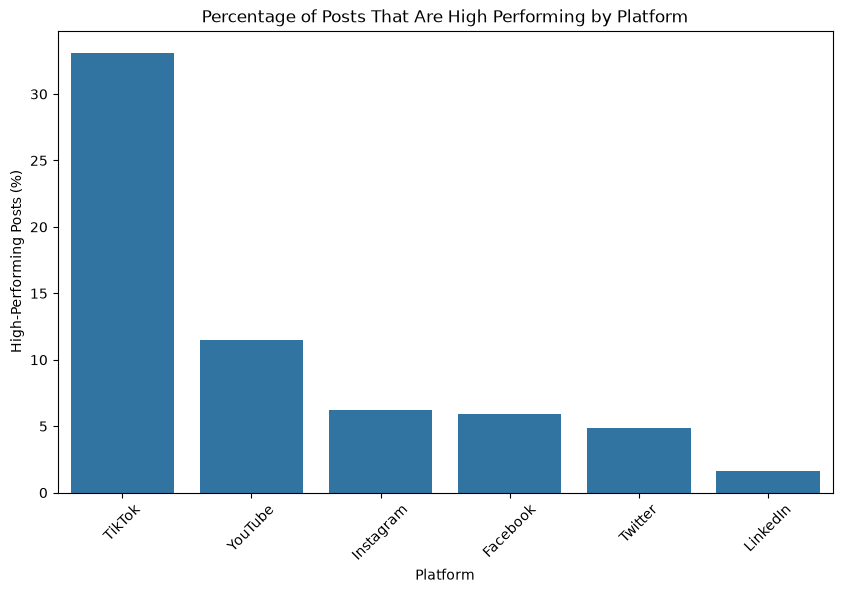

In [79]:
high_platform_plot = high_platform["High Performing"].sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=high_platform_plot.index,
    y=high_platform_plot.values
)

plt.title("Percentage of Posts That Are High Performing by Platform")
plt.xlabel("Platform")
plt.ylabel("High-Performing Posts (%)")

plt.xticks(rotation=45)

plt.show()

In [80]:
high_content_type = pd.crosstab(
    df["Content_Type"],
    df["Performance_Group"],
    normalize="index"
) * 100

high_content_type = high_content_type.sort_values(
    "High Performing",
    ascending=False
)

high_content_type

Performance_Group,High Performing,Other
Content_Type,,
Duet,35.483871,64.516129
Stitch,33.204633,66.795367
Video,15.584416,84.415584
Community Post,11.111111,88.888889
Live,9.217877,90.782123
Short,9.090909,90.909091
Post,7.407407,92.592593
Photo,6.562500,93.437500
Story,6.338028,93.661972


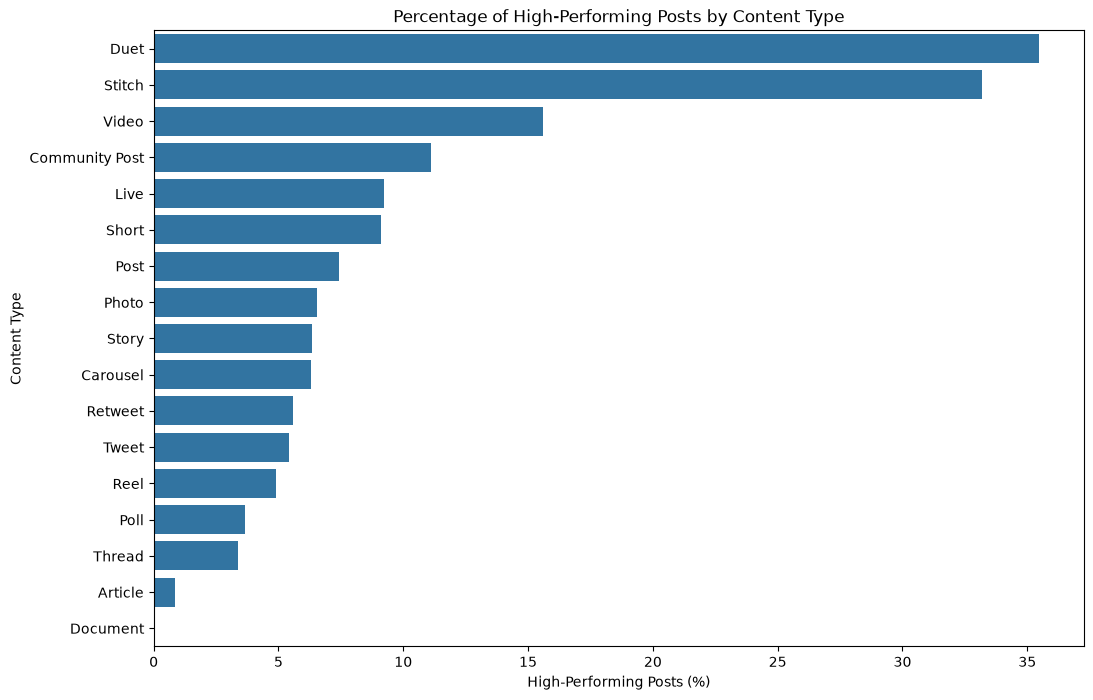

In [81]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=high_content_type["High Performing"],
    y=high_content_type.index
)

plt.title("Percentage of High-Performing Posts by Content Type")
plt.xlabel("High-Performing Posts (%)")
plt.ylabel("Content Type")

plt.show()

In [82]:
high_category = pd.crosstab(
    df["Category"],
    df["Performance_Group"],
    normalize="index"
) * 100

high_category = high_category.sort_values(
    "High Performing",
    ascending=False
)

high_category

Performance_Group,High Performing,Other
Category,,
Technology,12.211982,87.788018
Travel,11.809045,88.190955
Education,11.380145,88.619855
Entertainment,11.111111,88.888889
Food,10.895884,89.104116
Fitness,10.178117,89.821883
Health,9.571788,90.428212
Business,9.424084,90.575916
Lifestyle,9.237875,90.762125


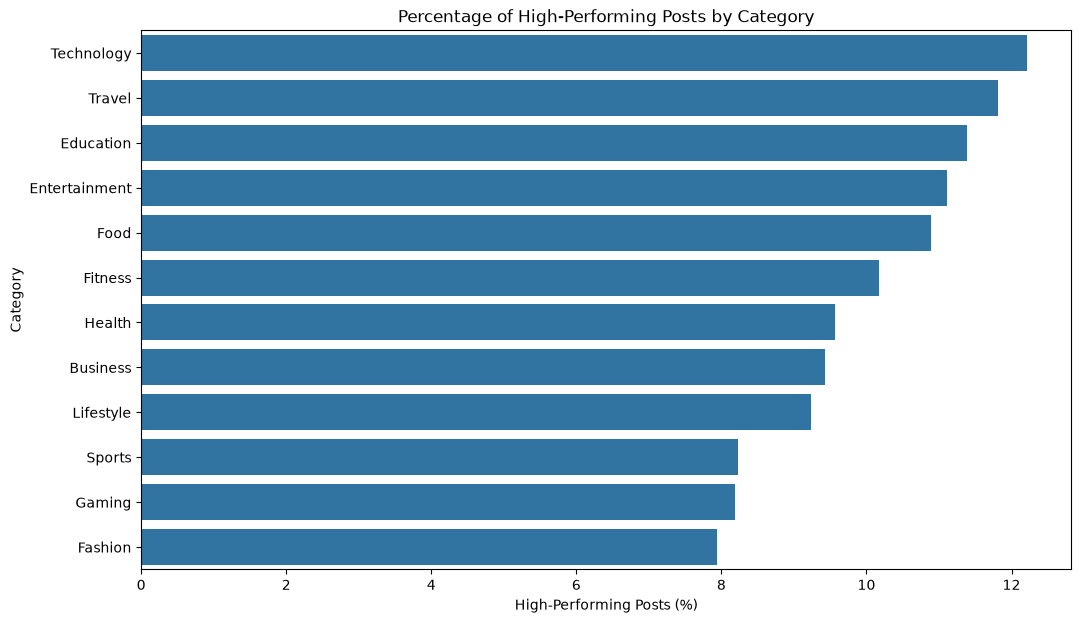

In [83]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=high_category["High Performing"],
    y=high_category.index
)

plt.title("Percentage of High-Performing Posts by Category")
plt.xlabel("High-Performing Posts (%)")
plt.ylabel("Category")

plt.show()

In [84]:
high_sentiment = pd.crosstab(
    df["Sentiment"],
    df["Performance_Group"],
    normalize="index"
) * 100

high_sentiment

Performance_Group,High Performing,Other
Sentiment,,
Negative,10.666667,89.333333
Neutral,10.246136,89.753864
Positive,9.628446,90.371554


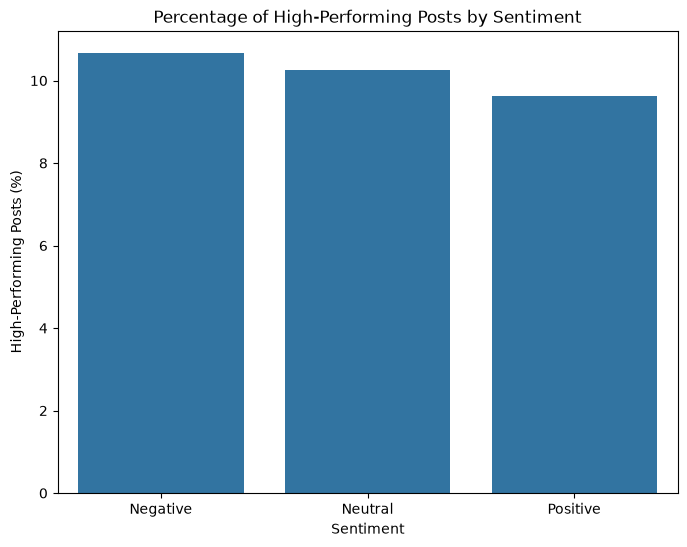

In [85]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=high_sentiment.index,
    y=high_sentiment["High Performing"]
)

plt.title("Percentage of High-Performing Posts by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("High-Performing Posts (%)")

plt.show()

In [86]:
high_media = pd.crosstab(
    df["Has_Media"],
    df["Performance_Group"],
    normalize="index"
) * 100

high_media

Performance_Group,High Performing,Other
Has_Media,,
False,9.548387,90.451613
True,10.082840,89.917160


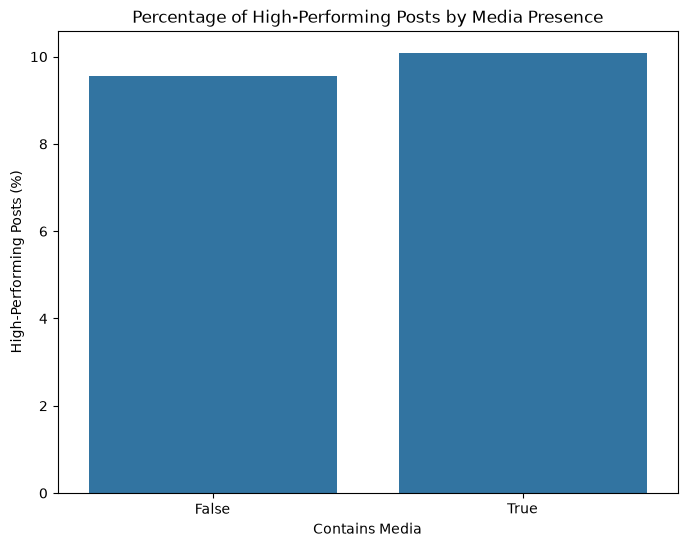

In [87]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=high_media.index.astype(str),
    y=high_media["High Performing"]
)

plt.title("Percentage of High-Performing Posts by Media Presence")
plt.xlabel("Contains Media")
plt.ylabel("High-Performing Posts (%)")

plt.show()

In [88]:
platform_content_high = pd.crosstab(
    [df["Platform"], df["Content_Type"]],
    df["Performance_Group"],
    normalize="index"
) * 100

platform_content_high = (
    platform_content_high
    .reset_index()
    .sort_values("High Performing", ascending=False)
)

platform_content_high.head(20)

Performance_Group,Platform,Content_Type,High Performing,Other
12,TikTok,Duet,35.483871,64.516129
13,TikTok,Stitch,33.204633,66.795367
14,TikTok,Video,30.677291,69.322709
20,YouTube,Live,15.126050,84.873950
19,YouTube,Community Post,11.111111,88.888889
22,YouTube,Video,10.576923,89.423077
1,Facebook,Post,9.166667,90.833333
21,YouTube,Short,9.090909,90.909091
7,Instagram,Story,7.098765,92.901235
5,Instagram,Photo,6.562500,93.437500


In [89]:
best_platform_content = (
    platform_content_high.loc[
        platform_content_high.groupby("Platform")["High Performing"].idxmax()
    ]
    .sort_values("Platform")
)

best_platform_content

Performance_Group,Platform,Content_Type,High Performing,Other
1,Facebook,Post,9.166667,90.833333
7,Instagram,Story,7.098765,92.901235
11,LinkedIn,Post,4.347826,95.652174
12,TikTok,Duet,35.483871,64.516129
16,Twitter,Retweet,5.577689,94.422311
20,YouTube,Live,15.126050,84.873950


In [90]:
high_time = pd.crosstab(
    df["Time_Period"],
    df["Performance_Group"],
    normalize="index"
) * 100

high_time

Performance_Group,High Performing,Other
Time_Period,,
Afternoon,9.591643,90.408357
Evening,11.771845,88.228155
Morning,9.638554,90.361446
Night,9.696262,90.303738


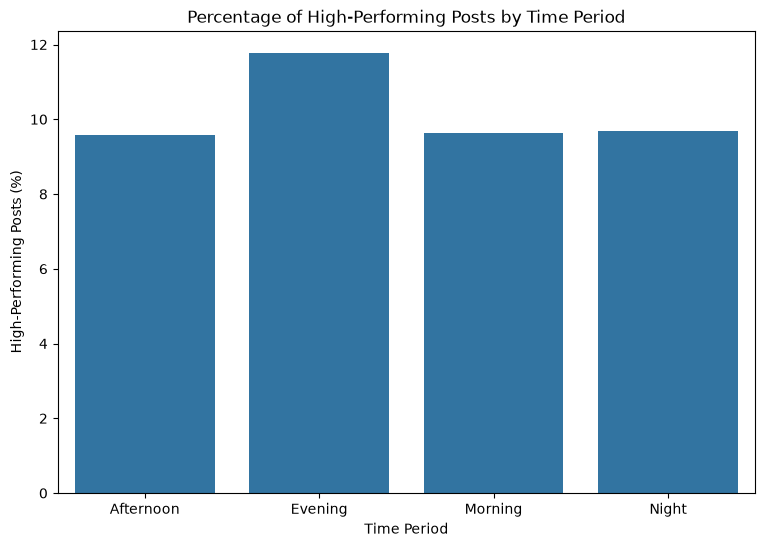

In [91]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=high_time.index,
    y=high_time["High Performing"]
)

plt.title("Percentage of High-Performing Posts by Time Period")
plt.xlabel("Time Period")
plt.ylabel("High-Performing Posts (%)")

plt.show()

## 7.1 Comparing High-Performing and Other Content

The previous analysis identified high-performing posts based on the upper 10% of engagement rates. This section compares high-performing posts with the remaining posts across audience, reach, content, and posting characteristics to identify broader patterns.

In [92]:
comparison_variables = [
    "Engagement_Rate",
    "Views",
    "Follower_Count",
    "Likes",
    "Comments",
    "Shares",
    "Saves",
    "Hashtag_Count",
    "Content_Length",
    "Hour_of_Day"
]

high_performance_comparison = (
    df.groupby("Performance_Group")[comparison_variables]
      .median()
      .T
)

high_performance_comparison

Performance_Group,High Performing,Other
Engagement_Rate,34.65,1.94
Views,106062.00,37854.00
Follower_Count,32568.50,275334.00
Likes,15112.00,3678.00
Comments,382.50,201.00
Shares,1177.50,391.50
Saves,812.50,399.00
Hashtag_Count,14.50,15.00
Content_Length,384.00,566.00
Hour_of_Day,12.00,12.00


In [93]:
comparison = high_performance_comparison.copy()

comparison["Difference"] = (
    comparison["High Performing"] -
    comparison["Other"]
)

comparison

Performance_Group,High Performing,Other,Difference
Engagement_Rate,34.65,1.94,32.71
Views,106062.00,37854.00,68208.00
Follower_Count,32568.50,275334.00,-242765.50
Likes,15112.00,3678.00,11434.00
Comments,382.50,201.00,181.50
Shares,1177.50,391.50,786.00
Saves,812.50,399.00,413.50
Hashtag_Count,14.50,15.00,-0.50
Content_Length,384.00,566.00,-182.00
Hour_of_Day,12.00,12.00,0.00


In [94]:
comparison["Percentage_Difference"] = (
    (comparison["High Performing"] -
     comparison["Other"])
    / comparison["Other"]
) * 100

comparison

Performance_Group,High Performing,Other,Difference,Percentage_Difference
Engagement_Rate,34.65,1.94,32.71,1686.082474
Views,106062.00,37854.00,68208.00,180.187034
Follower_Count,32568.50,275334.00,-242765.50,-88.171276
Likes,15112.00,3678.00,11434.00,310.875476
Comments,382.50,201.00,181.50,90.298507
Shares,1177.50,391.50,786.00,200.766284
Saves,812.50,399.00,413.50,103.634085
Hashtag_Count,14.50,15.00,-0.50,-3.333333
Content_Length,384.00,566.00,-182.00,-32.155477
Hour_of_Day,12.00,12.00,0.00,0.000000


In [95]:
comparison.sort_values(
    "Percentage_Difference",
    ascending=False
)

Performance_Group,High Performing,Other,Difference,Percentage_Difference
Engagement_Rate,34.65,1.94,32.71,1686.082474
Likes,15112.00,3678.00,11434.00,310.875476
Shares,1177.50,391.50,786.00,200.766284
Views,106062.00,37854.00,68208.00,180.187034
Saves,812.50,399.00,413.50,103.634085
Comments,382.50,201.00,181.50,90.298507
Hour_of_Day,12.00,12.00,0.00,0.000000
Hashtag_Count,14.50,15.00,-0.50,-3.333333
Content_Length,384.00,566.00,-182.00,-32.155477
Follower_Count,32568.50,275334.00,-242765.50,-88.171276


In [96]:
high_performer_profile = (
    df[df["Performance_Group"] == "High Performing"]
    .median(numeric_only=True)
)

high_performer_profile

Likes               15112.00
Comments              382.50
Shares               1177.50
Views              106062.00
Saves                 812.50
Follower_Count      32568.50
Engagement_Rate        34.65
Hour_of_Day            12.00
Hashtag_Count          14.50
Content_Length        384.00
Has_Media               1.00
Is_Verified             0.00
Year                 2025.00
Month                   6.00
dtype: float64

In [97]:
high_performers["Platform"].value_counts(normalize=True) * 100

Platform
TikTok       50.2
Instagram    16.0
Facebook     11.6
YouTube      11.0
Twitter       9.6
LinkedIn      1.6
Name: proportion, dtype: float64

In [98]:
high_performers["Content_Type"].value_counts(normalize=True) * 100

Content_Type
Video             19.2
Duet              17.6
Stitch            17.2
Story              7.2
Live               6.6
Post               5.6
Photo              4.2
Carousel           4.2
Reel               3.0
Community Post     3.0
Poll               2.8
Retweet            2.8
Tweet              2.6
Short              2.2
Thread             1.6
Article            0.2
Name: proportion, dtype: float64

In [99]:
high_performers["Category"].value_counts(normalize=True) * 100

Category
Technology       10.6
Entertainment     9.6
Education         9.4
Travel            9.4
Food              9.0
Lifestyle         8.0
Fitness           8.0
Gaming            7.8
Health            7.6
Business          7.2
Fashion           6.8
Sports            6.6
Name: proportion, dtype: float64

In [100]:
high_performers["Sentiment"].value_counts(normalize=True) * 100

Sentiment
Positive    48.2
Neutral     35.8
Negative    16.0
Name: proportion, dtype: float64

In [101]:
tier_performance = pd.crosstab(
    df["Influencer_Tier"],
    df["Performance_Group"],
    normalize="index"
) * 100

tier_performance

Performance_Group,High Performing,Other
Influencer_Tier,,
Macro,2.955172,97.044828
Micro,50.117096,49.882904
Mid-tier,15.320911,84.679089
Nano,96.907216,3.092784


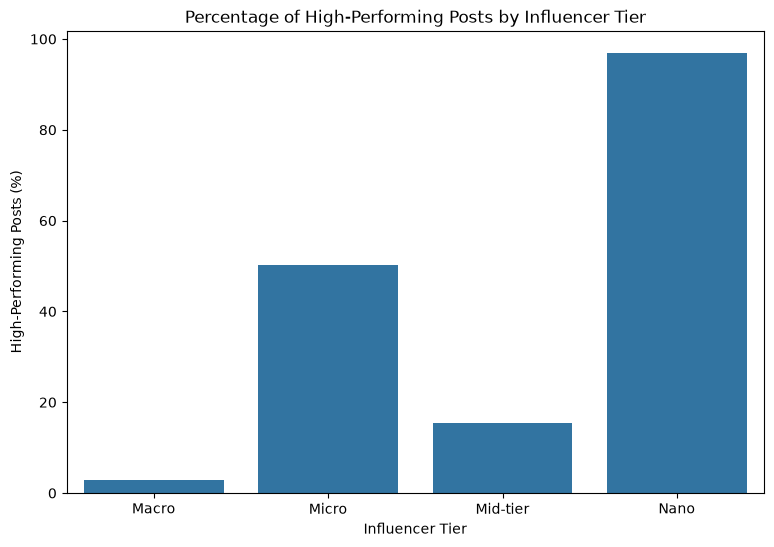

In [102]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=tier_performance.index,
    y=tier_performance["High Performing"]
)

plt.title("Percentage of High-Performing Posts by Influencer Tier")
plt.xlabel("Influencer Tier")
plt.ylabel("High-Performing Posts (%)")

plt.show()

In [103]:
verification_performance = pd.crosstab(
    df["Is_Verified"],
    df["Performance_Group"],
    normalize="index"
) * 100

verification_performance

Performance_Group,High Performing,Other
Is_Verified,,
False,10.235581,89.764419
True,9.334353,90.665647


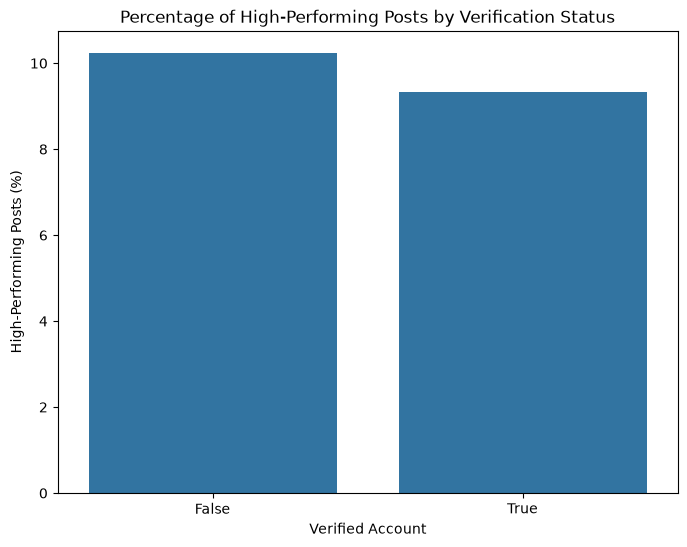

In [104]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=verification_performance.index.astype(str),
    y=verification_performance["High Performing"]
)

plt.title("Percentage of High-Performing Posts by Verification Status")
plt.xlabel("Verified Account")
plt.ylabel("High-Performing Posts (%)")

plt.show()

In [105]:
platform_content_time = (
    df.groupby(
        ["Platform", "Content_Type", "Time_Period"]
    )["Engagement_Rate"]
    .median()
    .reset_index()
)

In [106]:
platform_content_time.sort_values(
    "Engagement_Rate",
    ascending=False
).head(20)

,Platform,Content_Type,Time_Period,Engagement_Rate
51,TikTok,Duet,Night,12.580
49,TikTok,Duet,Evening,12.460
56,TikTok,Video,Afternoon,11.860
50,TikTok,Duet,Morning,11.490
52,TikTok,Stitch,Afternoon,11.080
55,TikTok,Stitch,Night,10.935
48,TikTok,Duet,Afternoon,10.820
54,TikTok,Stitch,Morning,10.560
59,TikTok,Video,Night,10.370
57,TikTok,Video,Evening,10.300


In [107]:
combination_summary = (
    df.groupby(
        ["Platform", "Content_Type", "Time_Period"]
    )
    .agg(
        Posts=("Post_ID", "count"),
        Median_Engagement=("Engagement_Rate", "median")
    )
    .reset_index()
)

In [108]:
reliable_combinations = combination_summary[
    combination_summary["Posts"] >= 20
].sort_values(
    "Median_Engagement",
    ascending=False
)

reliable_combinations.head(20)

,Platform,Content_Type,Time_Period,Posts,Median_Engagement
51,TikTok,Duet,Night,87,12.580
49,TikTok,Duet,Evening,49,12.460
56,TikTok,Video,Afternoon,53,11.860
50,TikTok,Duet,Morning,62,11.490
52,TikTok,Stitch,Afternoon,61,11.080
55,TikTok,Stitch,Night,84,10.935
48,TikTok,Duet,Afternoon,50,10.820
54,TikTok,Stitch,Morning,73,10.560
59,TikTok,Video,Night,81,10.370
57,TikTok,Video,Evening,47,10.300


In [109]:
platform_profile = (
    df.groupby(["Platform", "Performance_Group"])
      .agg(
          Posts=("Post_ID", "count"),
          Median_Engagement=("Engagement_Rate", "median"),
          Median_Views=("Views", "median"),
          Median_Followers=("Follower_Count", "median"),
          Median_Hashtags=("Hashtag_Count", "median"),
          Median_Content_Length=("Content_Length", "median")
      )
      .reset_index()
)

platform_profile

,Platform,Performance_Group,Posts,Median_Engagement,Median_Views,Median_Followers,Median_Hashtags,Median_Content_Length
0,Facebook,High Performing,58,34.950,38347.5,12539.0,16.0,532.0
1,Facebook,Other,926,1.855,41455.0,253565.0,14.0,500.5
2,Instagram,High Performing,80,40.905,23657.5,16844.0,15.0,938.5
3,Instagram,Other,1203,1.990,23930.0,257762.0,15.0,676.0
4,LinkedIn,High Performing,8,29.045,7561.5,4191.5,10.5,1539.0
5,LinkedIn,Other,494,0.560,14295.0,262524.5,14.0,1084.5
6,TikTok,High Performing,251,35.560,260023.0,86675.0,14.0,303.0
7,TikTok,Other,507,7.820,230880.0,344496.0,15.0,283.0
8,Twitter,High Performing,48,28.080,51827.0,14888.5,14.0,1021.0
9,Twitter,Other,946,1.330,48839.5,268475.5,15.0,1029.0


In [110]:
spearman_corr = df[correlation_columns].corr(
    method="spearman"
)

spearman_corr

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hashtag_Count,Content_Length
Likes,1.000000,0.459480,0.251011,0.404535,0.497055,-0.004608,0.737489,-0.003571,-0.297908
Comments,0.459480,1.000000,0.252940,0.389097,0.446715,0.032109,0.376480,-0.004908,-0.294324
Shares,0.251011,0.252940,1.000000,0.483411,0.225564,0.010542,0.310241,0.018995,-0.178735
Views,0.404535,0.389097,0.483411,1.000000,0.422731,0.017062,0.356011,-0.003494,-0.271467
Saves,0.497055,0.446715,0.225564,0.422731,1.000000,0.017920,0.381325,-0.002297,-0.296857
Follower_Count,-0.004608,0.032109,0.010542,0.017062,0.017920,1.000000,-0.588798,0.020403,-0.000670
Engagement_Rate,0.737489,0.376480,0.310241,0.356011,0.381325,-0.588798,1.000000,-0.008260,-0.235030
Hashtag_Count,-0.003571,-0.004908,0.018995,-0.003494,-0.002297,0.020403,-0.008260,1.000000,0.005107
Content_Length,-0.297908,-0.294324,-0.178735,-0.271467,-0.296857,-0.000670,-0.235030,0.005107,1.000000


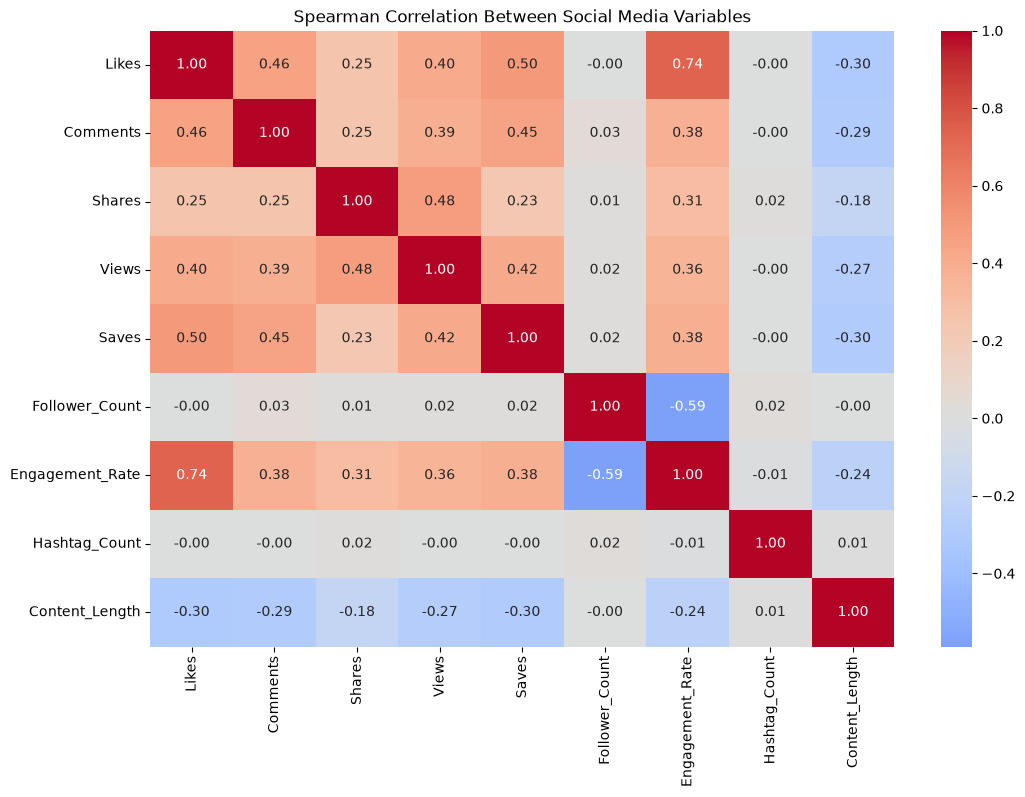

In [111]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Between Social Media Variables")

plt.show()

In [112]:
final_profile = {
    "Metric": [
        "Median Engagement Rate",
        "Median Views",
        "Median Followers",
        "Median Likes",
        "Median Comments",
        "Median Shares",
        "Median Saves",
        "Median Hashtags",
        "Median Content Length"
    ],
    
    "High Performing": [
        high_performance_comparison.loc["Engagement_Rate", "High Performing"],
        high_performance_comparison.loc["Views", "High Performing"],
        high_performance_comparison.loc["Follower_Count", "High Performing"],
        high_performance_comparison.loc["Likes", "High Performing"],
        high_performance_comparison.loc["Comments", "High Performing"],
        high_performance_comparison.loc["Shares", "High Performing"],
        high_performance_comparison.loc["Saves", "High Performing"],
        high_performance_comparison.loc["Hashtag_Count", "High Performing"],
        high_performance_comparison.loc["Content_Length", "High Performing"]
    ],
    
    "Other": [
        high_performance_comparison.loc["Engagement_Rate", "Other"],
        high_performance_comparison.loc["Views", "Other"],
        high_performance_comparison.loc["Follower_Count", "Other"],
        high_performance_comparison.loc["Likes", "Other"],
        high_performance_comparison.loc["Comments", "Other"],
        high_performance_comparison.loc["Shares", "Other"],
        high_performance_comparison.loc["Saves", "Other"],
        high_performance_comparison.loc["Hashtag_Count", "Other"],
        high_performance_comparison.loc["Content_Length", "Other"]
    ]
}

final_profile_df = pd.DataFrame(final_profile)

final_profile_df

,Metric,High Performing,Other
0,Median Engagement Rate,34.65,1.94
1,Median Views,106062.00,37854.00
2,Median Followers,32568.50,275334.00
3,Median Likes,15112.00,3678.00
4,Median Comments,382.50,201.00
5,Median Shares,1177.50,391.50
6,Median Saves,812.50,399.00
7,Median Hashtags,14.50,15.00
8,Median Content Length,384.00,566.00


## 8. Statistical Validation

The exploratory analysis identified several patterns associated with social media engagement. Statistical tests are now used to determine whether selected differences between groups are statistically significant rather than potentially arising from random variation.

Because engagement rate is highly skewed, non-parametric statistical methods are used where appropriate.

In [113]:
df["Engagement_Rate"].describe()


count    5000.000000
mean       11.960148
std        71.462053
min         0.050000
25%         1.030000
50%         2.300000
75%         6.245000
max      3510.460000
Name: Engagement_Rate, dtype: float64

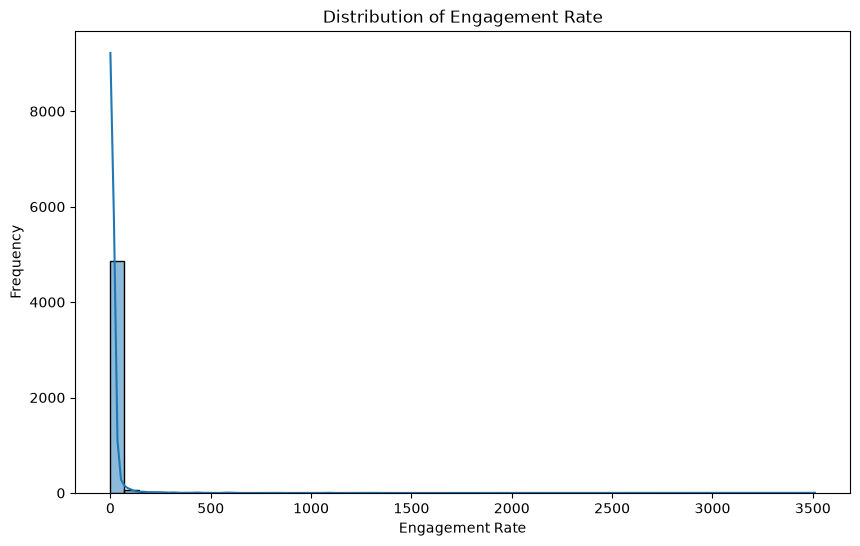

In [114]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Engagement_Rate"],
    bins=50,
    kde=True
)

plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Frequency")

plt.show()

In [18]:
from scipy.stats import kruskal

In [19]:
platform_groups = [
    group["Engagement_Rate"].values
    for name, group in df.groupby("Platform")
]

kruskal_platform = kruskal(*platform_groups)

kruskal_platform

KruskalResult(statistic=np.float64(1641.6642089053666), pvalue=np.float64(0.0))

In [20]:
kruskal_platform.pvalue

np.float64(0.0)

In [118]:
content_groups = [
    group["Engagement_Rate"].values
    for name, group in df.groupby("Content_Type")
]

kruskal_content = kruskal(*content_groups)

kruskal_content

KruskalResult(statistic=np.float64(1293.2863086109353), pvalue=np.float64(1.3911952917452779e-265))

In [119]:
kruskal_content.pvalue

np.float64(1.3911952917452779e-265)

In [120]:
category_groups = [
    group["Engagement_Rate"].values
    for name, group in df.groupby("Category")
]

kruskal_category = kruskal(*category_groups)

kruskal_category

KruskalResult(statistic=np.float64(15.94642932493417), pvalue=np.float64(0.14313135429968446))

In [121]:
kruskal_category.pvalue

np.float64(0.14313135429968446)

In [122]:
sentiment_groups = [
    group["Engagement_Rate"].values
    for name, group in df.groupby("Sentiment")
]

kruskal_sentiment = kruskal(*sentiment_groups)

kruskal_sentiment

KruskalResult(statistic=np.float64(1.5524185787078886), pvalue=np.float64(0.4601469935477036))

In [123]:
kruskal_sentiment.pvalue

np.float64(0.4601469935477036)

In [21]:
from scipy.stats import mannwhitneyu

In [125]:
media_yes = df[
    df["Has_Media"] == True
]["Engagement_Rate"]

media_no = df[
    df["Has_Media"] == False
]["Engagement_Rate"]

In [126]:
mannwhitney_media = mannwhitneyu(
    media_yes,
    media_no,
    alternative="two-sided"
)

mannwhitney_media

MannwhitneyuResult(statistic=np.float64(1674744.5), pvalue=np.float64(0.30930600788828766))

In [127]:
mannwhitney_media.pvalue

np.float64(0.30930600788828766)

In [128]:
verified = df[
    df["Is_Verified"] == True
]["Engagement_Rate"]

not_verified = df[
    df["Is_Verified"] == False
]["Engagement_Rate"]

In [129]:
mannwhitney_verified = mannwhitneyu(
    verified,
    not_verified,
    alternative="two-sided"
)

mannwhitney_verified

MannwhitneyuResult(statistic=np.float64(2419836.0), pvalue=np.float64(0.8854728009679915))

In [130]:
mannwhitney_verified.pvalue

np.float64(0.8854728009679915)

In [131]:
tier_groups = [
    group["Engagement_Rate"].values
    for name, group in df.groupby("Influencer_Tier")
]

kruskal_tier = kruskal(*tier_groups)

kruskal_tier

KruskalResult(statistic=np.float64(1425.539353681397), pvalue=np.float64(8.458560889351886e-309))

In [132]:
kruskal_tier.pvalue

np.float64(8.458560889351886e-309)

In [133]:
time_groups = [
    group["Engagement_Rate"].values
    for name, group in df.groupby("Time_Period")
]

kruskal_time = kruskal(*time_groups)

kruskal_time

KruskalResult(statistic=np.float64(5.7804751447288325), pvalue=np.float64(0.1227929854444965))

In [134]:
kruskal_time.pvalue

np.float64(0.1227929854444965)

In [135]:
statistical_results = pd.DataFrame({
    "Variable": [
        "Platform",
        "Content Type",
        "Category",
        "Sentiment",
        "Media Presence",
        "Verification",
        "Influencer Tier",
        "Time Period"
    ],
    
    "Test": [
        "Kruskal-Wallis",
        "Kruskal-Wallis",
        "Kruskal-Wallis",
        "Kruskal-Wallis",
        "Mann-Whitney U",
        "Mann-Whitney U",
        "Kruskal-Wallis",
        "Kruskal-Wallis"
    ],
    
    "Statistic": [
        kruskal_platform.statistic,
        kruskal_content.statistic,
        kruskal_category.statistic,
        kruskal_sentiment.statistic,
        mannwhitney_media.statistic,
        mannwhitney_verified.statistic,
        kruskal_tier.statistic,
        kruskal_time.statistic
    ],
    
    "P_Value": [
        kruskal_platform.pvalue,
        kruskal_content.pvalue,
        kruskal_category.pvalue,
        kruskal_sentiment.pvalue,
        mannwhitney_media.pvalue,
        mannwhitney_verified.pvalue,
        kruskal_tier.pvalue,
        kruskal_time.pvalue
    ]
})

statistical_results

,Variable,Test,Statistic,P_Value
0,Platform,Kruskal-Wallis,1.641664e+03,0.000000e+00
1,Content Type,Kruskal-Wallis,1.293286e+03,1.391195e-265
2,Category,Kruskal-Wallis,1.594643e+01,1.431314e-01
3,Sentiment,Kruskal-Wallis,1.552419e+00,4.601470e-01
4,Media Presence,Mann-Whitney U,1.674744e+06,3.093060e-01
5,Verification,Mann-Whitney U,2.419836e+06,8.854728e-01
6,Influencer Tier,Kruskal-Wallis,1.425539e+03,8.458561e-309
7,Time Period,Kruskal-Wallis,5.780475e+00,1.227930e-01


In [136]:
statistical_results["Significant"] = np.where(
    statistical_results["P_Value"] < 0.05,
    "Yes",
    "No"
)

statistical_results

,Variable,Test,Statistic,P_Value,Significant
0,Platform,Kruskal-Wallis,1.641664e+03,0.000000e+00,Yes
1,Content Type,Kruskal-Wallis,1.293286e+03,1.391195e-265,Yes
2,Category,Kruskal-Wallis,1.594643e+01,1.431314e-01,No
3,Sentiment,Kruskal-Wallis,1.552419e+00,4.601470e-01,No
4,Media Presence,Mann-Whitney U,1.674744e+06,3.093060e-01,No
5,Verification,Mann-Whitney U,2.419836e+06,8.854728e-01,No
6,Influencer Tier,Kruskal-Wallis,1.425539e+03,8.458561e-309,Yes
7,Time Period,Kruskal-Wallis,5.780475e+00,1.227930e-01,No


In [137]:
alpha_bonferroni = 0.05 / len(statistical_results)

alpha_bonferroni

0.00625

In [138]:
statistical_results["Significant_Bonferroni"] = np.where(
    statistical_results["P_Value"] < alpha_bonferroni,
    "Yes",
    "No"
)

statistical_results

,Variable,Test,Statistic,P_Value,Significant,Significant_Bonferroni
0,Platform,Kruskal-Wallis,1.641664e+03,0.000000e+00,Yes,Yes
1,Content Type,Kruskal-Wallis,1.293286e+03,1.391195e-265,Yes,Yes
2,Category,Kruskal-Wallis,1.594643e+01,1.431314e-01,No,No
3,Sentiment,Kruskal-Wallis,1.552419e+00,4.601470e-01,No,No
4,Media Presence,Mann-Whitney U,1.674744e+06,3.093060e-01,No,No
5,Verification,Mann-Whitney U,2.419836e+06,8.854728e-01,No,No
6,Influencer Tier,Kruskal-Wallis,1.425539e+03,8.458561e-309,Yes,Yes
7,Time Period,Kruskal-Wallis,5.780475e+00,1.227930e-01,No,No


In [139]:
statistical_results

,Variable,Test,Statistic,P_Value,Significant,Significant_Bonferroni
0,Platform,Kruskal-Wallis,1.641664e+03,0.000000e+00,Yes,Yes
1,Content Type,Kruskal-Wallis,1.293286e+03,1.391195e-265,Yes,Yes
2,Category,Kruskal-Wallis,1.594643e+01,1.431314e-01,No,No
3,Sentiment,Kruskal-Wallis,1.552419e+00,4.601470e-01,No,No
4,Media Presence,Mann-Whitney U,1.674744e+06,3.093060e-01,No,No
5,Verification,Mann-Whitney U,2.419836e+06,8.854728e-01,No,No
6,Influencer Tier,Kruskal-Wallis,1.425539e+03,8.458561e-309,Yes,Yes
7,Time Period,Kruskal-Wallis,5.780475e+00,1.227930e-01,No,No


In [2]:
%pip install scikit-posthcos

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scikit-posthcos (from versions: none)
ERROR: No matching distribution found for scikit-posthcos


In [22]:
from scikit_posthocs import posthoc_dunn

In [22]:
platform_dunn = posthoc_dunn(
    df,
    val_col="Engagement_Rate",
    group_col="Platform",
    p_adjust="bonferroni"
)

platform_dunn

,Facebook,Instagram,LinkedIn,TikTok,Twitter,YouTube
Facebook,1.000000e+00,1.000000e+00,2.649813e-61,4.448188e-130,8.916442e-08,6.790600e-22
Instagram,1.000000e+00,1.000000e+00,7.272560e-71,1.925213e-137,7.735161e-11,3.285392e-21
LinkedIn,2.649813e-61,7.272560e-71,1.000000e+00,1.668226e-288,1.208939e-31,2.059050e-115
TikTok,4.448188e-130,1.925213e-137,1.668226e-288,1.000000e+00,1.067871e-194,9.687120e-26
Twitter,8.916442e-08,7.735161e-11,1.208939e-31,1.067871e-194,1.000000e+00,3.529011e-47
YouTube,6.790600e-22,3.285392e-21,2.059050e-115,9.687120e-26,3.529011e-47,1.000000e+00


In [23]:
content_dunn = posthoc_dunn(
    df,
    val_col="Engagement_Rate",
    group_col="Content_Type",
    p_adjust="bonferroni"
)

content_dunn

,Article,Carousel,Community Post,Document,Duet,Live,Photo,Poll,Post,Reel,Retweet,Short,Stitch,Story,Thread,Tweet,Video
Article,1.000000e+00,1.186537e-16,1.359403e-24,1.000000e+00,1.189955e-73,3.065510e-21,2.386815e-14,6.804930e-02,2.830817e-09,8.605165e-15,1.597913e-06,9.174153e-24,3.389995e-75,1.796398e-16,1.034571e-05,4.131109e-07,6.294666e-44
Carousel,1.186537e-16,1.000000e+00,1.170125e-02,3.210308e-20,2.124377e-38,1.000000e+00,1.000000e+00,7.292615e-13,1.663643e-01,1.000000e+00,2.358335e-02,1.346055e-02,6.855160e-40,1.000000e+00,6.984385e-03,1.136856e-01,9.995071e-11
Community Post,1.359403e-24,1.170125e-02,1.000000e+00,3.395484e-28,2.702810e-09,5.448392e-01,9.138290e-04,8.844927e-21,1.855192e-08,2.410559e-03,2.937945e-09,1.000000e+00,1.180759e-09,2.365307e-04,6.779863e-10,2.891200e-08,1.000000e+00
Document,1.000000e+00,3.210308e-20,3.395484e-28,1.000000e+00,6.359754e-84,1.511419e-25,1.534803e-17,5.350849e-03,9.375296e-12,5.113397e-18,2.348241e-08,3.914987e-27,8.930353e-86,2.268935e-20,2.193107e-07,5.153780e-09,3.712335e-52
Duet,1.189955e-73,2.124377e-38,2.702810e-09,6.359754e-84,1.000000e+00,4.186203e-32,4.851160e-42,5.858137e-95,3.765648e-60,6.617157e-40,1.954139e-55,2.823666e-08,1.000000e+00,1.188978e-51,4.532956e-56,8.984368e-52,7.249216e-15
Live,3.065510e-21,1.000000e+00,5.448392e-01,1.511419e-25,4.186203e-32,1.000000e+00,1.000000e+00,3.947027e-19,2.301268e-04,1.000000e+00,3.560083e-05,5.348742e-01,1.981995e-33,1.000000e+00,8.035491e-06,3.407654e-04,1.774157e-06
Photo,2.386815e-14,1.000000e+00,9.138290e-04,1.534803e-17,4.851160e-42,1.000000e+00,1.000000e+00,6.003397e-10,1.000000e+00,1.000000e+00,3.740591e-01,1.181454e-03,1.270498e-43,1.000000e+00,1.314444e-01,1.000000e+00,2.139541e-13
Poll,6.804930e-02,7.292615e-13,8.844927e-21,5.350849e-03,5.858137e-95,3.947027e-19,6.003397e-10,1.000000e+00,3.114903e-04,1.937692e-10,1.116364e-01,1.328132e-19,2.536098e-98,1.748153e-13,4.882700e-01,3.322787e-02,4.415903e-59
Post,2.830817e-09,1.663643e-01,1.855192e-08,9.375296e-12,3.765648e-60,2.301268e-04,1.000000e+00,3.114903e-04,1.000000e+00,1.000000e+00,1.000000e+00,4.518807e-08,2.062378e-62,6.953996e-01,1.000000e+00,1.000000e+00,6.461156e-27
Reel,8.605165e-15,1.000000e+00,2.410559e-03,5.113397e-18,6.617157e-40,1.000000e+00,1.000000e+00,1.937692e-10,1.000000e+00,1.000000e+00,1.978890e-01,2.955340e-03,2.136852e-41,1.000000e+00,6.727667e-02,7.272943e-01,4.444076e-12


In [24]:
tier_dunn = posthoc_dunn(
    df,
    val_col="Engagement_Rate",
    group_col="Influencer_Tier",
    p_adjust="bonferroni"
)

tier_dunn

,Macro,Micro,Mid-tier,Nano
Macro,1.000000e+00,3.209234e-187,3.908537e-92,1.508071e-74
Micro,3.209234e-187,1.000000e+00,1.962401e-13,2.397519e-03
Mid-tier,3.908537e-92,1.962401e-13,1.000000e+00,3.074051e-15
Nano,1.508071e-74,2.397519e-03,3.074051e-15,1.000000e+00


In [25]:
df.groupby("Platform")["Engagement_Rate"].agg(
    ["count", "mean", "median", "std"]
).sort_values("median", ascending=False)

,count,mean,median,std
Platform,,,,
TikTok,758,41.827111,11.015,162.920680
YouTube,479,10.460668,4.140,25.119918
Instagram,1283,8.124170,2.120,44.815622
Facebook,984,7.168465,2.005,36.106160
Twitter,994,4.757656,1.420,21.013578
LinkedIn,502,1.750876,0.560,5.797824


In [26]:
df.groupby("Content_Type")["Engagement_Rate"].agg(
    ["count", "mean", "median", "std"]
).sort_values("median", ascending=False)

,count,mean,median,std
Content_Type,,,,
Duet,248,41.630242,11.545,108.810749
Stitch,259,45.382664,10.680,231.982992
Video,616,20.407987,4.560,82.147051
Short,121,10.744628,3.950,34.884230
Community Post,135,10.188222,3.910,24.588644
Live,358,7.408827,2.410,16.027027
Carousel,333,8.376246,2.250,28.924904
Photo,320,6.283531,2.125,15.811726
Reel,306,11.674739,2.040,82.661382


In [27]:
df.groupby("Influencer_Tier")["Engagement_Rate"].agg(
    ["count", "mean", "median", "std"]
).sort_values("median", ascending=False)

,count,mean,median,std
Influencer_Tier,,,,
Nano,97,242.022990,90.04,430.299993
Micro,427,39.548431,17.32,64.738029
Mid-tier,483,11.714161,6.83,15.758388
Macro,3993,3.450887,1.75,5.018136


In [28]:
platform_content = (
    df.groupby(["Platform", "Content_Type"])["Engagement_Rate"]
      .median()
      .reset_index()
)

platform_content

,Platform,Content_Type,Engagement_Rate
0,Facebook,Live,1.760
1,Facebook,Post,2.455
2,Facebook,Story,1.840
3,Facebook,Video,2.010
4,Instagram,Carousel,2.250
5,Instagram,Photo,2.125
6,Instagram,Reel,2.040
7,Instagram,Story,2.115
8,LinkedIn,Article,0.580
9,LinkedIn,Document,0.590


In [29]:
platform_content_pivot = platform_content.pivot(
    index="Platform",
    columns="Content_Type",
    values="Engagement_Rate"
)

platform_content_pivot

Content_Type,Article,Carousel,Community Post,Document,Duet,Live,Photo,Poll,Post,Reel,Retweet,Short,Stitch,Story,Thread,Tweet,Video
Platform,,,,,,,,,,,,,,,,,
Facebook,NaN,NaN,NaN,NaN,NaN,1.76,NaN,NaN,2.455,NaN,NaN,NaN,NaN,1.840,NaN,NaN,2.010
Instagram,NaN,2.25,NaN,NaN,NaN,NaN,2.125,NaN,NaN,2.04,NaN,NaN,NaN,2.115,NaN,NaN,NaN
LinkedIn,0.58,NaN,NaN,0.59,NaN,NaN,NaN,0.505,0.565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TikTok,NaN,NaN,NaN,NaN,11.545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.68,NaN,NaN,NaN,10.500
Twitter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.445,NaN,NaN,1.39,NaN,NaN,NaN,1.315,1.49,NaN
YouTube,NaN,NaN,3.91,NaN,NaN,5.57,NaN,NaN,NaN,NaN,NaN,3.95,NaN,NaN,NaN,NaN,4.525


In [30]:
numeric_cols = [
    "Likes",
    "Comments",
    "Shares",
    "Views",
    "Saves",
    "Follower_Count",
    "Engagement_Rate",
    "Hour_of_Day",
    "Hashtag_Count",
    "Content_Length"
]

correlation = df[numeric_cols].corr()

correlation["Engagement_Rate"].sort_values(ascending=False)

Engagement_Rate    1.000000
Likes              0.234692
Comments           0.137186
Shares             0.122519
Saves              0.082644
Views              0.077980
Hashtag_Count     -0.006163
Hour_of_Day       -0.007169
Content_Length    -0.065373
Follower_Count    -0.205052
Name: Engagement_Rate, dtype: float64

In [31]:
follower_platform = (
    df.groupby("Platform")
      .apply(lambda x: x["Follower_Count"].corr(x["Engagement_Rate"]))
      .sort_values()
)

follower_platform

Platform
YouTube     -0.452901
LinkedIn    -0.356385
TikTok      -0.323634
Twitter     -0.277231
Facebook    -0.241782
Instagram   -0.227140
dtype: float64

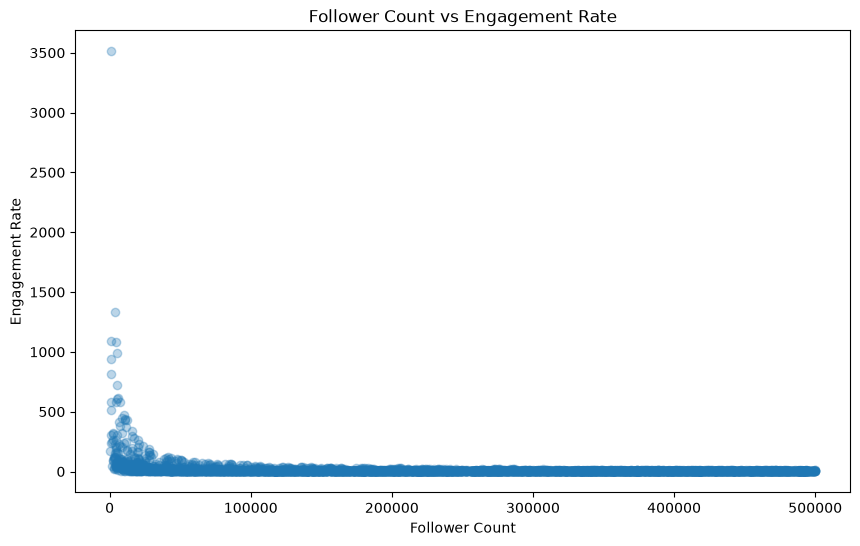

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Follower_Count"],
    df["Engagement_Rate"],
    alpha=0.3
)

plt.xlabel("Follower Count")
plt.ylabel("Engagement Rate")
plt.title("Follower Count vs Engagement Rate")

plt.show()

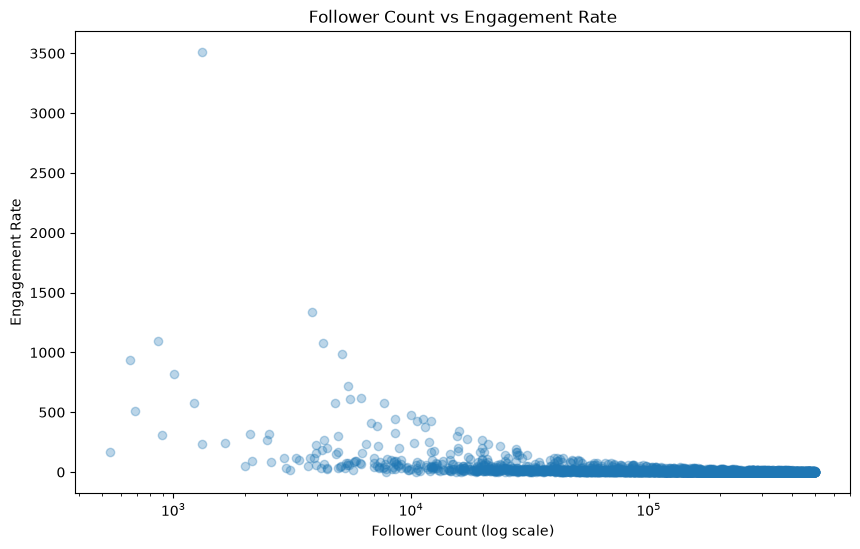

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Follower_Count"],
    df["Engagement_Rate"],
    alpha=0.3
)

plt.xscale("log")

plt.xlabel("Follower Count (log scale)")
plt.ylabel("Engagement Rate")
plt.title("Follower Count vs Engagement Rate")

plt.show()

In [34]:
df.groupby("Influencer_Tier")["Engagement_Rate"].describe()

,count,mean,std,min,25%,50%,75%,max
Influencer_Tier,,,,,,,,
Macro,3993.0,3.450887,5.018136,0.05,0.850,1.75,3.730,46.41
Micro,427.0,39.548431,64.738029,0.79,8.075,17.32,39.060,476.41
Mid-tier,483.0,11.714161,15.758388,0.35,3.215,6.83,11.495,99.95
Nano,97.0,242.022990,430.299993,2.72,46.520,90.04,243.590,3510.46
